In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/test-image/test.jpeg
/kaggle/input/blood-cell-detection-dataset/LICENSE
/kaggle/input/blood-cell-detection-dataset/.gitignore
/kaggle/input/blood-cell-detection-dataset/README.md
/kaggle/input/blood-cell-detection-dataset/annotations.csv
/kaggle/input/blood-cell-detection-dataset/images/image-79.png
/kaggle/input/blood-cell-detection-dataset/images/image-64.png
/kaggle/input/blood-cell-detection-dataset/images/image-48.png
/kaggle/input/blood-cell-detection-dataset/images/image-109.png
/kaggle/input/blood-cell-detection-dataset/images/image-25.png
/kaggle/input/blood-cell-detection-dataset/images/image-110.png
/kaggle/input/blood-cell-detection-dataset/images/image-89.png
/kaggle/input/blood-cell-detection-dataset/images/image-108.png
/kaggle/input/blood-cell-detection-dataset/images/image-45.png
/kaggle/input/blood-cell-detection-dataset/images/image-20.png
/kaggle/input/blood-cell-detection-dataset/images/image-105.png
/kaggle/input/blood-cell-detection-dataset/images/i

In [3]:
print("Installing required packages...")
!pip install -q ultralytics
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q scikit-image

Installing required packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 62.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.6 MB/s eta 0:00:0000:0100:01
   

In [4]:
import pandas as pd
import numpy as np
import os
import shutil
import glob
import random
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage
from skimage import morphology, measure, segmentation
from pathlib import Path
from IPython.display import display, Image as IPImage

print("Libraries imported successfully!")
print(f"CUDA Available: {torch.cuda.is_available()}")

Libraries imported successfully!
CUDA Available: True


In [5]:
class MorphologyProcessor:
    """Handles all mathematical morphology operations for cell analysis - IMPROVED VERSION"""
    
    @staticmethod
    def create_structuring_element(shape='ellipse', size=5):
        """Create structuring elements for morphological operations"""
        if shape == 'ellipse':
            return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))
        elif shape == 'disk':
            return morphology.disk(size // 2)
        elif shape == 'square':
            return cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
        elif shape == 'cross':
            return cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))
        return None
    
    @staticmethod
    def clean_mask(mask, operation='close', kernel_size=3):
        """Clean binary mask using morphological operations"""
        kernel = MorphologyProcessor.create_structuring_element('ellipse', kernel_size)
        mask_binary = (mask > 0).astype(np.uint8) * 255
        
        if operation == 'open':
            cleaned = cv2.morphologyEx(mask_binary, cv2.MORPH_OPEN, kernel)
        elif operation == 'close':
            cleaned = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)
        elif operation == 'both':
            cleaned = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)
            cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)
        else:
            cleaned = mask_binary
            
        return (cleaned > 0).astype(np.uint8)
    
    @staticmethod
    def fill_holes(mask):
        """Fill holes in binary mask using morphological reconstruction"""
        mask_binary = (mask > 0).astype(bool)
        filled = ndimage.binary_fill_holes(mask_binary)
        return filled.astype(np.uint8)
    
    @staticmethod
    def remove_border_objects(mask, buffer=5):
        """Remove objects touching image borders"""
        cleared = segmentation.clear_border(mask, buffer_size=buffer)
        return cleared
    
    @staticmethod
    def separate_touching_cells(mask, min_distance=5):
        """
        Separate touching/overlapping cells using improved watershed segmentation
        
        Parameters:
        - mask: Binary mask with potentially touching cells
        - min_distance: Minimum distance between cell centers (peaks)
        
        Returns:
        - Labeled mask with separated cells
        """
        if mask.sum() == 0:
            return mask
        
        # Ensure binary mask
        mask_binary = (mask > 0).astype(np.uint8)
        
        # Distance transform - larger values at cell centers
        distance = ndimage.distance_transform_edt(mask_binary)
        
        # Find local maxima (cell centers) with minimum distance constraint
        from scipy import ndimage as ndi
        
        # Use more sophisticated peak finding
        # First, apply gaussian smoothing to distance transform
        distance_smooth = ndimage.gaussian_filter(distance, sigma=1)
        
        # Find local maxima
        local_max = morphology.h_maxima(distance_smooth, h=distance_smooth.max() * 0.25)
        
        # Apply minimum distance between peaks
        coords = np.column_stack(np.where(local_max))
        if len(coords) > 1:
            # Remove peaks that are too close to each other
            from scipy.spatial.distance import pdist, squareform
            distances = squareform(pdist(coords))
            np.fill_diagonal(distances, np.inf)
            
            # Iteratively remove closest peaks
            while distances.min() < min_distance:
                i, j = np.unravel_index(distances.argmin(), distances.shape)
                # Remove the peak with lower distance transform value
                if distance_smooth[coords[i, 0], coords[i, 1]] < distance_smooth[coords[j, 0], coords[j, 1]]:
                    remove_idx = i
                else:
                    remove_idx = j
                
                coords = np.delete(coords, remove_idx, axis=0)
                distances = squareform(pdist(coords))
                np.fill_diagonal(distances, np.inf)
                
                if len(coords) <= 1:
                    break
        
        # Create markers from filtered peaks
        markers = np.zeros_like(mask_binary)
        for idx, (r, c) in enumerate(coords):
            markers[r, c] = idx + 1
        
        # If only one marker or no markers, return labeled mask
        if markers.max() <= 1:
            return measure.label(mask_binary)
        
        # Dilate markers slightly to ensure they're in the regions
        markers = morphology.dilation(markers, morphology.disk(2))
        markers = markers * mask_binary  # Keep only markers inside mask
        
        # Watershed segmentation using negative distance as elevation
        labels = segmentation.watershed(-distance, markers, mask=mask_binary, watershed_line=True)
        
        return labels
    
    @staticmethod
    def extract_morphological_features(mask):
        """Extract comprehensive morphological features from a binary mask"""
        if mask.sum() == 0:
            return None
        
        # Ensure proper labeling
        labeled = measure.label(mask)
        if labeled.max() == 0:
            return None
        
        # Get properties of the largest region (in case of multiple)
        props_list = measure.regionprops(labeled)
        if not props_list:
            return None
        
        # Use the largest region
        props = max(props_list, key=lambda x: x.area)
        
        area = props.area
        perimeter = props.perimeter
        
        # Calculate circularity (0 = line, 1 = perfect circle)
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        
        # Calculate compactness
        compactness = perimeter / (2 * np.sqrt(np.pi * area)) if area > 0 else 0
        
        # Calculate convexity
        convexity = props.area / props.convex_area if props.convex_area > 0 else 0
        
        return {
            'area': area,
            'perimeter': perimeter,
            'circularity': circularity,
            'compactness': compactness,
            'solidity': props.solidity,
            'convexity': convexity,
            'eccentricity': props.eccentricity,
            'equivalent_diameter': props.equivalent_diameter,
            'major_axis_length': props.major_axis_length,
            'minor_axis_length': props.minor_axis_length,
            'orientation': props.orientation,
            'centroid': props.centroid,
            'bbox': props.bbox,
            'extent': props.extent,
            'filled_area': props.filled_area
        }
    
    @staticmethod
    def filter_by_size(mask, min_area=100, max_area=10000):
        """Remove objects outside size range"""
        labeled = measure.label(mask)
        
        # Remove small objects
        filtered = morphology.remove_small_objects(labeled, min_size=min_area)
        
        # Remove large objects
        props = measure.regionprops(filtered)
        for prop in props:
            if prop.area > max_area:
                filtered[filtered == prop.label] = 0
        
        return (filtered > 0).astype(np.uint8)
    
    @staticmethod
    def filter_by_circularity(mask, min_circ=0.3, max_circ=1.0):
        """Filter objects by circularity to remove non-cell artifacts"""
        labeled = measure.label(mask)
        filtered = np.zeros_like(mask)
        
        props = measure.regionprops(labeled)
        for prop in props:
            area = prop.area
            perimeter = prop.perimeter
            if perimeter > 0:
                circularity = (4 * np.pi * area) / (perimeter ** 2)
                if min_circ <= circularity <= max_circ:
                    filtered[labeled == prop.label] = 1
        
        return filtered.astype(np.uint8)

print("Improved Morphology module loaded!")


Improved Morphology module loaded!


In [6]:
# Kaggle paths
IMAGES_DIR = "/kaggle/input/blood-cell-detection-dataset/images"
ANN_PATH = "/kaggle/input/blood-cell-detection-dataset/annotations.csv"
OUTPUT_DIR = "datasets/blood_cells"
LABELS_DIR = "labels"

IMG_WIDTH = 256
IMG_HEIGHT = 256

print("Loading annotations...")
ann_df = pd.read_csv(ANN_PATH)
print(f"Total annotations: {len(ann_df)}")
print(f"Unique images: {ann_df['image'].nunique()}")
print(f"Class distribution:\n{ann_df['label'].value_counts()}")

# Create labels directory
os.makedirs(LABELS_DIR, exist_ok=True)
# Class mapping
class_map = {'rbc': 0, 'wbc': 1}
ann_df['class_id'] = ann_df['label'].map(class_map)
# Convert to YOLO format
ann_df['x_center'] = ((ann_df['xmin'] + ann_df['xmax']) / 2) / IMG_WIDTH
ann_df['y_center'] = ((ann_df['ymin'] + ann_df['ymax']) / 2) / IMG_HEIGHT
ann_df['box_width'] = (ann_df['xmax'] - ann_df['xmin']) / IMG_WIDTH
ann_df['box_height'] = (ann_df['ymax'] - ann_df['ymin']) / IMG_HEIGHT

# Save label files
for image_name, group in ann_df.groupby('image'):
    label_file = os.path.join(LABELS_DIR, image_name.replace('.png', '.txt'))
    group[['class_id', 'x_center', 'y_center', 'box_width', 'box_height']] \
        .to_csv(label_file, sep=' ', header=False, index=False, float_format='%.6f')

print("Labels created successfully!")


Loading annotations...
Total annotations: 2340
Unique images: 100
Class distribution:
label
rbc    2237
wbc     103
Name: count, dtype: int64
Labels created successfully!


In [7]:
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

random.seed(42)

image_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.png")))
random.shuffle(image_paths)

total = len(image_paths)
n_train = int(total * TRAIN_RATIO)
n_val = int(total * VAL_RATIO)
train_files = image_paths[:n_train]
val_files = image_paths[n_train:n_train + n_val]
test_files = image_paths[n_train + n_val:]

splits = {'train': train_files, 'val': val_files, 'test': test_files}

# Create directories and copy files
for split, file_list in splits.items():
    img_out_dir = os.path.join(OUTPUT_DIR, split, "images")
    lbl_out_dir = os.path.join(OUTPUT_DIR, split, "labels")
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    for img_path in file_list:
        img_name = os.path.basename(img_path)
        lbl_name = img_name.replace('.png', '.txt')

        shutil.copy(img_path, os.path.join(img_out_dir, img_name))

        lbl_src = os.path.join(LABELS_DIR, lbl_name)
        lbl_dst = os.path.join(lbl_out_dir, lbl_name)
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, lbl_dst)

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

Train: 70, Val: 20, Test: 10


In [8]:
yaml_content = f"""train: /kaggle/working/datasets/blood_cells/train/images
val: /kaggle/working/datasets/blood_cells/val/images
test: /kaggle/working/datasets/blood_cells/test/images

nc: 2
names: ['rbc', 'wbc']
"""

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"YAML config saved to: {yaml_path}")

YAML config saved to: datasets/blood_cells/data.yaml


Starting YOLO training...
Ultralytics 8.3.228 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=30, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/blood_cells/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=115, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspectiv

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         20        474      0.985      0.978      0.992      0.873
                   rbc         20        454      0.982      0.957      0.989      0.847
                   wbc         20         20      0.988          1      0.995        0.9
Speed: 0.0ms preprocess, 1.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/train2
Training complete!
Best model saved at: runs/detect/train/weights/best.pt


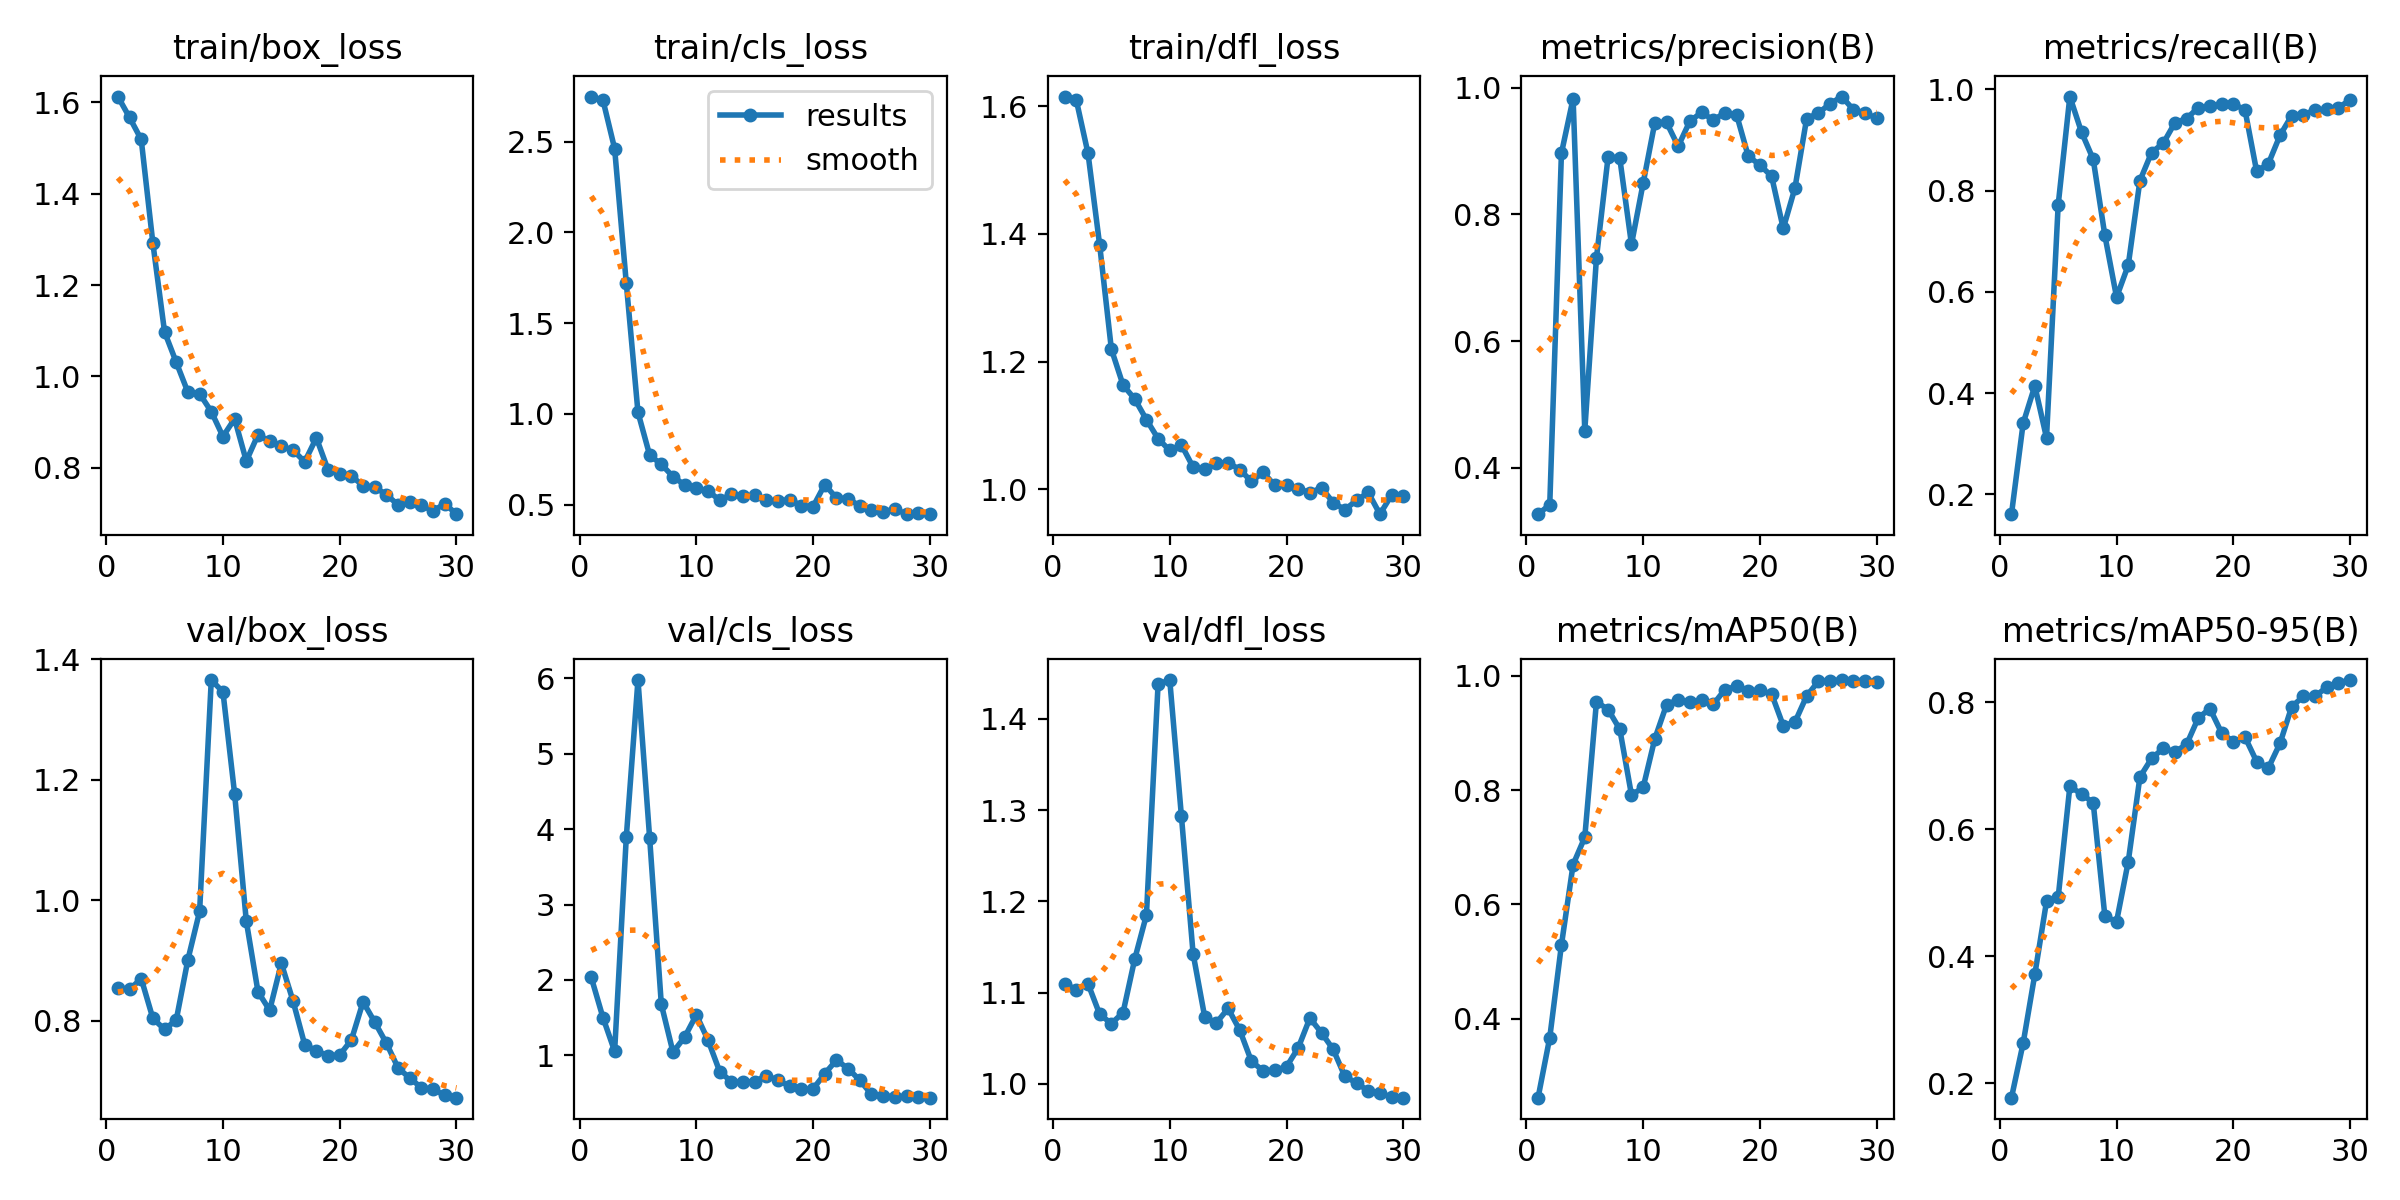

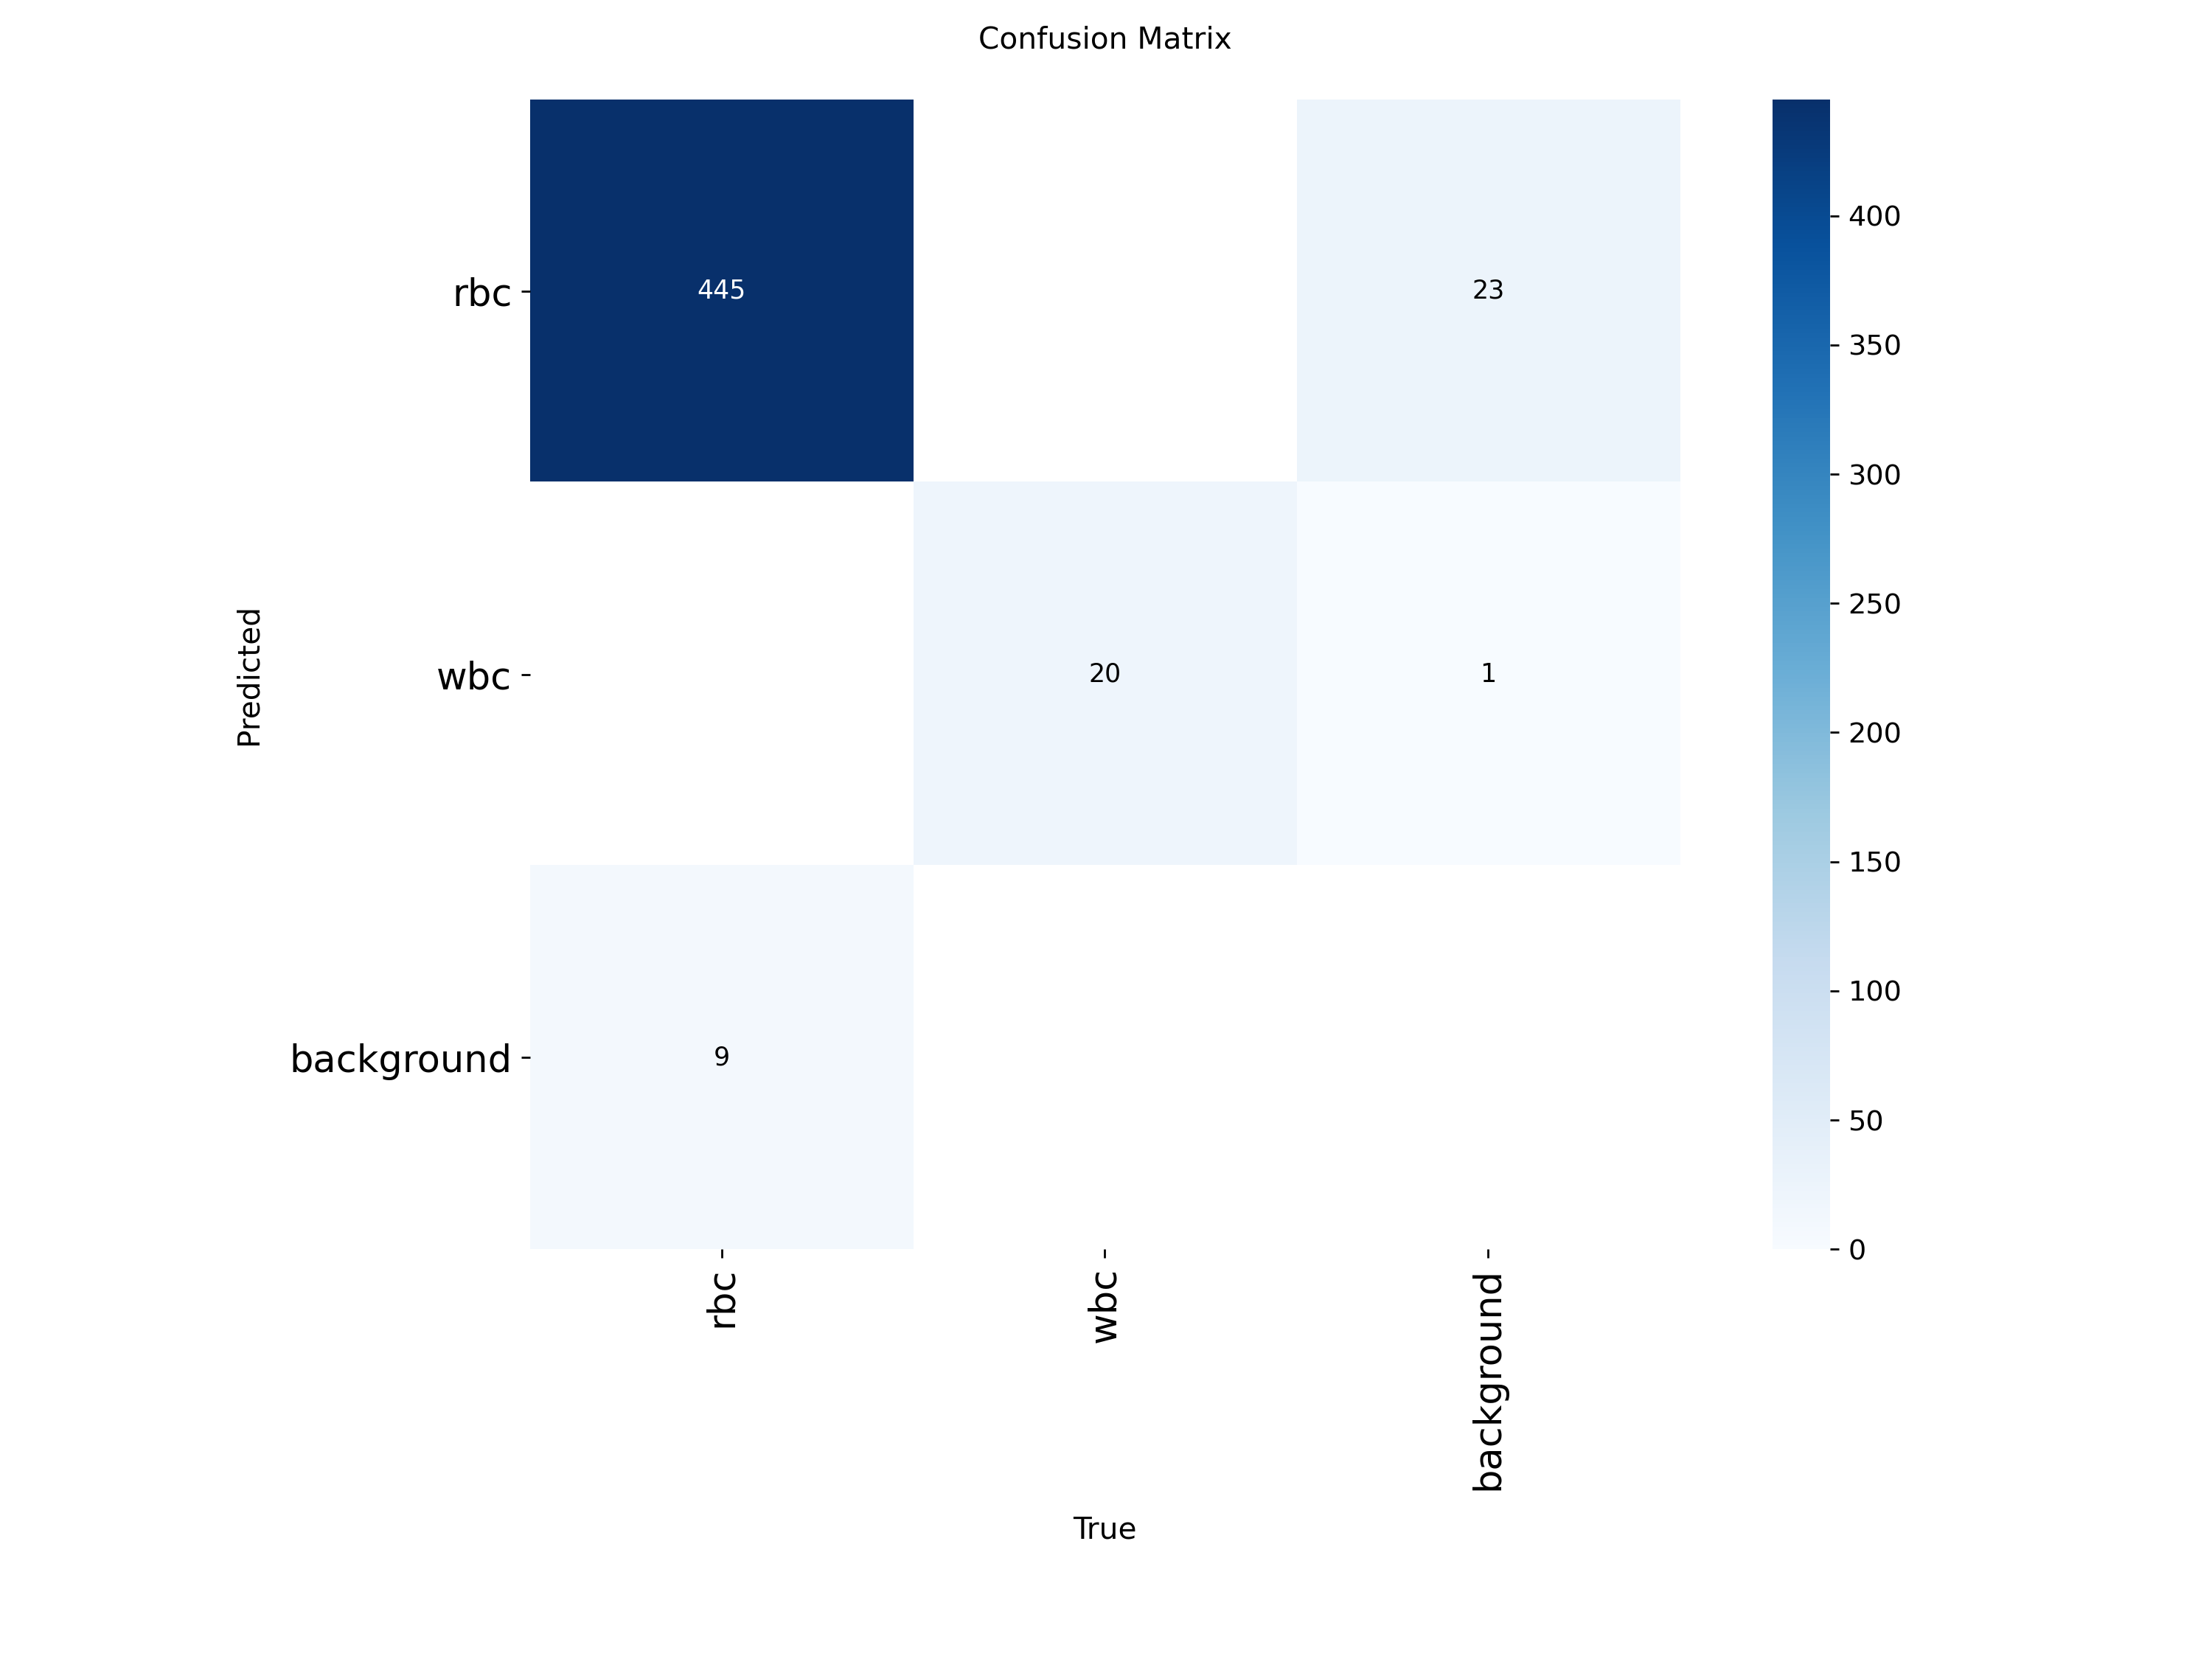

In [27]:
from ultralytics import YOLO
import torch

print("Starting YOLO training...")
model = YOLO('yolo11s.pt')

results = model.train(
    data=yaml_path,
    epochs=115,          # Higher limit, let patience handle early stopping
    imgsz=256,
    batch=30,
    patience=50,         # Increased patience for better convergence
    plots=True,
    device=0 if torch.cuda.is_available() else 'cpu',
    
    # Additional helpful parameters:
          # Save checkpoint every 10 epochs
    val=True,            # Enable validation
    cache=True,          # Cache images for faster training
    workers=8,           # Data loading workers
)

print("Training complete!")
print("Best model saved at: runs/detect/train/weights/best.pt")

# Show training results
from IPython.display import Image as IPImage, display
display(IPImage(filename='runs/detect/train/results.png'))
display(IPImage(filename='runs/detect/train/confusion_matrix.png'))

In [28]:
print("Downloading SAM model checkpoint...")
if not os.path.exists('sam_vit_h_4b8939.pth'):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
    print("SAM checkpoint downloaded!")
else:
    print("SAM checkpoint already exists!")

SAM checkpoint already exists!


In [29]:
from segment_anything import sam_model_registry, SamPredictor

class SAMSegmenter:
    """SAM-based segmentation with improved morphological refinement"""
    
    def __init__(self, checkpoint_path, model_type='vit_h'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        sam.to(device=self.device)
        self.predictor = SamPredictor(sam)
        self.morph = MorphologyProcessor()
        print(f"SAM loaded on {self.device}")
    
    def segment_with_boxes(self, image, bboxes, refine=True, use_point_prompts=True):
        """Segment cells using bounding boxes with improved morphological refinement"""
        if len(bboxes) == 0:
            return [], []
        
        # Ensure image is in correct format (H, W, 3) uint8 RGB
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)
        
        # Set image for SAM
        self.predictor.set_image(image)
        
        # Convert bboxes to correct format and device
        bboxes_tensor = torch.tensor(bboxes, dtype=torch.float32, device=self.device)
        
        # Transform boxes to SAM's input space
        transformed_boxes = self.predictor.transform.apply_boxes_torch(
            bboxes_tensor,
            image.shape[:2]
        )
        
        refined_masks = []
        features = []
        
        # Process each bounding box individually for better control
        for i in range(len(bboxes)):
            x1, y1, x2, y2 = bboxes[i]
            bbox_area = (x2 - x1) * (y2 - y1)
            
            # Calculate center point and additional points for better accuracy
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2
            
            # Prepare prompts
            if use_point_prompts:
                # Use multiple points for better cell boundary detection
                # Center point + 4 points slightly offset from center
                offset = min((x2 - x1), (y2 - y1)) * 0.15
                point_coords = torch.tensor([
                    [center_x, center_y],  # Center
                    [center_x + offset, center_y],  # Right
                    [center_x - offset, center_y],  # Left
                    [center_x, center_y + offset],  # Bottom
                    [center_x, center_y - offset],  # Top
                ], dtype=torch.float32, device=self.device)
                point_labels = torch.tensor([1, 1, 1, 1, 1], dtype=torch.int32, device=self.device)
                
                # Transform point coordinates to SAM's input space
                point_coords_transformed = self.predictor.transform.apply_coords_torch(
                    point_coords.unsqueeze(0),
                    image.shape[:2]
                ).squeeze(0)
                
                # Generate masks with both box and point prompts
                masks, scores, _ = self.predictor.predict_torch(
                    boxes=transformed_boxes[i:i+1],
                    point_coords=point_coords_transformed.unsqueeze(0),
                    point_labels=point_labels.unsqueeze(0),
                    multimask_output=True
                )
            else:
                # Generate masks with only box prompt
                masks, scores, _ = self.predictor.predict_torch(
                    boxes=transformed_boxes[i:i+1],
                    multimask_output=True,
                    point_coords=None,
                    point_labels=None
                )
            
            # SAM returns 3 masks - choose the best one with improved selection
            box_masks = masks[0]  # Shape: (3, H, W)
            box_scores = scores[0]  # Shape: (3,)
            
            # Smart mask selection strategy
            mask_areas = [box_masks[j].cpu().numpy().sum() for j in range(3)]
            
            # Filter out masks that are too small or too large
            valid_masks = []
            for j in range(3):
                area_ratio = mask_areas[j] / bbox_area
                # Valid masks should be 30-85% of bbox area (adjusted for better cell detection)
                if 0.3 <= area_ratio <= 0.85 and box_scores[j] > 0.5:
                    valid_masks.append((j, box_scores[j].item(), mask_areas[j], area_ratio))
            
            if not valid_masks:
                # If no valid masks, use highest score mask
                best_mask_idx = box_scores.argmax().item()
                mask_np = box_masks[best_mask_idx].cpu().numpy()
            else:
                # Choose mask with best balance of score and area
                def mask_quality_score(mask_info):
                    idx, score, area, ratio = mask_info
                    # Prefer masks around 55% of bbox area with high confidence
                    area_score = 1.0 - abs(ratio - 0.55) / 0.55
                    return score * 0.7 + area_score * 0.3
                
                best_mask_info = max(valid_masks, key=mask_quality_score)
                best_mask_idx = best_mask_info[0]
                mask_np = box_masks[best_mask_idx].cpu().numpy()
            
            # Validate mask quality
            if mask_np.sum() < 50:  # Skip nearly empty masks
                continue
            
            # Convert to binary uint8
            mask_binary = (mask_np > 0).astype(np.uint8)
            
            # Crop mask to bbox region to avoid artifacts
            mask_in_bbox = mask_binary[int(y1):int(y2), int(x1):int(x2)]
            if mask_in_bbox.sum() < 50:
                continue
                
            mask_cropped = np.zeros_like(mask_binary)
            mask_cropped[int(y1):int(y2), int(x1):int(x2)] = mask_in_bbox
            mask_binary = mask_cropped
            
            if refine:
                # IMPROVED Morphological refinement pipeline
                # Step 1: Fill small holes first (preserves cell structure)
                mask_filled = self.morph.fill_holes(mask_binary)
                
                # Step 2: Gentle closing to connect nearby regions (kernel=3)
                kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
                mask_closed = cv2.morphologyEx(mask_filled.astype(np.uint8), cv2.MORPH_CLOSE, kernel_close)
                
                # Step 3: Remove small noise with opening (kernel=2)
                kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
                mask_opened = cv2.morphologyEx(mask_closed, cv2.MORPH_OPEN, kernel_open)
                
                # Step 4: Smooth boundaries with gentle erosion then dilation
                kernel_smooth = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
                mask_eroded = cv2.erode(mask_opened, kernel_smooth, iterations=1)
                mask_smoothed = cv2.dilate(mask_eroded, kernel_smooth, iterations=1)
                
                # Step 5: Final hole filling to ensure no gaps
                mask_refined = self.morph.fill_holes(mask_smoothed)
                
                refined_masks.append(mask_refined.astype(np.uint8))
            else:
                refined_masks.append(mask_binary)
            
            # Extract features
            feat = self.morph.extract_morphological_features(refined_masks[-1])
            features.append(feat)
        
        return refined_masks, features

print("SAM Segmenter class loaded with improved morphology!")


SAM Segmenter class loaded with improved morphology!


In [30]:
def visualize_morphological_operations(image, bbox, sam_segmenter):
    """
    Visualize each morphological operation step-by-step
    Shows: Raw SAM -> Fill Holes -> Close -> Open -> Smooth -> Final
    """
    # Get raw SAM mask (without refinement)
    x1, y1, x2, y2 = bbox
    bbox_array = np.array([bbox])
    
    # Temporarily disable refinement
    sam_segmenter.predictor.set_image(image)
    bboxes_tensor = torch.tensor(bbox_array, dtype=torch.float32, device=sam_segmenter.device)
    transformed_boxes = sam_segmenter.predictor.transform.apply_boxes_torch(
        bboxes_tensor, image.shape[:2]
    )
    
    # Get center point
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    offset = min((x2 - x1), (y2 - y1)) * 0.15
    
    point_coords = torch.tensor([
        [center_x, center_y],
        [center_x + offset, center_y],
        [center_x - offset, center_y],
        [center_x, center_y + offset],
        [center_x, center_y - offset],
    ], dtype=torch.float32, device=sam_segmenter.device)
    point_labels = torch.tensor([1, 1, 1, 1, 1], dtype=torch.int32, device=sam_segmenter.device)
    
    point_coords_transformed = sam_segmenter.predictor.transform.apply_coords_torch(
        point_coords.unsqueeze(0), image.shape[:2]
    ).squeeze(0)
    
    masks, scores, _ = sam_segmenter.predictor.predict_torch(
        boxes=transformed_boxes[0:1],
        point_coords=point_coords_transformed.unsqueeze(0),
        point_labels=point_labels.unsqueeze(0),
        multimask_output=True
    )
    
    # Get best mask
    box_masks = masks[0]
    box_scores = scores[0]
    best_mask_idx = box_scores.argmax().item()
    mask_raw = box_masks[best_mask_idx].cpu().numpy()
    mask_binary = (mask_raw > 0).astype(np.uint8)
    
    # Crop to bbox
    mask_in_bbox = mask_binary[int(y1):int(y2), int(x1):int(x2)]
    mask_cropped = np.zeros_like(mask_binary)
    mask_cropped[int(y1):int(y2), int(x1):int(x2)] = mask_in_bbox
    
    # Apply each morphological operation step by step
    print("Applying morphological operations step-by-step...")
    
    # Step 1: Fill holes
    mask_1_filled = ndimage.binary_fill_holes(mask_cropped).astype(np.uint8)
    area_1 = mask_1_filled.sum()
    print(f"  1. Fill Holes: {area_1} pixels")
    
    # Step 2: Closing (connect nearby regions)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_2_closed = cv2.morphologyEx(mask_1_filled, cv2.MORPH_CLOSE, kernel_close)
    area_2 = mask_2_closed.sum()
    print(f"  2. Closing (k=3): {area_2} pixels (change: {area_2 - area_1:+d})")
    
    # Step 3: Opening (remove noise)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    mask_3_opened = cv2.morphologyEx(mask_2_closed, cv2.MORPH_OPEN, kernel_open)
    area_3 = mask_3_opened.sum()
    print(f"  3. Opening (k=2): {area_3} pixels (change: {area_3 - area_2:+d})")
    
    # Step 4: Smoothing (erosion + dilation)
    kernel_smooth = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    mask_4_eroded = cv2.erode(mask_3_opened, kernel_smooth, iterations=1)
    mask_4_smoothed = cv2.dilate(mask_4_eroded, kernel_smooth, iterations=1)
    area_4 = mask_4_smoothed.sum()
    print(f"  4. Smoothing: {area_4} pixels (change: {area_4 - area_3:+d})")
    
    # Step 5: Final hole filling
    mask_5_final = ndimage.binary_fill_holes(mask_4_smoothed).astype(np.uint8)
    area_5 = mask_5_final.sum()
    print(f"  5. Final Fill: {area_5} pixels (change: {area_5 - area_4:+d})")
    print(f"  Total change: {area_5 - mask_cropped.sum():+d} pixels ({(area_5 - mask_cropped.sum()) / mask_cropped.sum() * 100:+.1f}%)")
    
    # Create visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Crop region for all visualizations
    pad = 20
    y1_crop = max(0, int(y1) - pad)
    y2_crop = min(image.shape[0], int(y2) + pad)
    x1_crop = max(0, int(x1) - pad)
    x2_crop = min(image.shape[1], int(x2) + pad)
    
    image_crop = image[y1_crop:y2_crop, x1_crop:x2_crop]
    
    # Row 1: Steps 0-3
    steps = [
        ("0. Raw SAM Output", mask_cropped, mask_cropped.sum()),
        ("1. Fill Holes", mask_1_filled, area_1),
        ("2. Closing (k=3)", mask_2_closed, area_2),
        ("3. Opening (k=2)", mask_3_opened, area_3),
    ]
    
    for idx, (title, mask, area) in enumerate(steps):
        ax = axes[0, idx]
        mask_crop = mask[y1_crop:y2_crop, x1_crop:x2_crop]
        
        # Show image with mask overlay
        ax.imshow(image_crop)
        overlay = np.zeros_like(image_crop)
        overlay[:, :, 0] = mask_crop * 255
        ax.imshow(overlay, alpha=0.5)
        
        # Draw contours
        contours, _ = cv2.findContours(mask_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if len(contour) > 2:
                ax.plot(contour[:, 0, 0], contour[:, 0, 1], 'lime', linewidth=2)
        
        ax.set_title(f"{title}\nArea: {area} px", fontsize=10)
        ax.axis('off')
    
    # Row 2: Steps 4-6 + comparison
    steps2 = [
        ("4. Smoothing", mask_4_smoothed, area_4),
        ("5. Final (Fill Holes)", mask_5_final, area_5),
        ("Before vs After", None, None),
        ("Difference Map", None, None),
    ]
    
    for idx, (title, mask, area) in enumerate(steps2):
        ax = axes[1, idx]
        
        if idx < 2:
            mask_crop = mask[y1_crop:y2_crop, x1_crop:x2_crop]
            ax.imshow(image_crop)
            overlay = np.zeros_like(image_crop)
            overlay[:, :, 0] = mask_crop * 255
            ax.imshow(overlay, alpha=0.5)
            
            contours, _ = cv2.findContours(mask_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for contour in contours:
                if len(contour) > 2:
                    ax.plot(contour[:, 0, 0], contour[:, 0, 1], 'lime', linewidth=2)
            
            ax.set_title(f"{title}\nArea: {area} px", fontsize=10)
        
        elif idx == 2:
            # Before vs After
            ax.imshow(image_crop)
            
            # Raw mask in red
            mask_raw_crop = mask_cropped[y1_crop:y2_crop, x1_crop:x2_crop]
            overlay_raw = np.zeros_like(image_crop)
            overlay_raw[:, :, 0] = mask_raw_crop * 255
            ax.imshow(overlay_raw, alpha=0.3)
            
            # Final mask in green
            mask_final_crop = mask_5_final[y1_crop:y2_crop, x1_crop:x2_crop]
            overlay_final = np.zeros_like(image_crop)
            overlay_final[:, :, 1] = mask_final_crop * 255
            ax.imshow(overlay_final, alpha=0.3)
            
            ax.set_title("Red=Raw, Green=Final\nYellow=Overlap", fontsize=10)
        
        else:
            # Difference map
            diff = mask_5_final.astype(int) - mask_cropped.astype(int)
            diff_crop = diff[y1_crop:y2_crop, x1_crop:x2_crop]
            
            # Create colored difference map
            diff_vis = np.zeros((*diff_crop.shape, 3), dtype=np.uint8)
            diff_vis[diff_crop > 0] = [0, 255, 0]  # Added pixels (green)
            diff_vis[diff_crop < 0] = [255, 0, 0]  # Removed pixels (red)
            diff_vis[diff_crop == 0] = [128, 128, 128]  # Unchanged (gray)
            
            ax.imshow(diff_vis)
            ax.set_title(f"Green=Added, Red=Removed\nNet: {diff.sum():+d} px", fontsize=10)
        
        ax.axis('off')
    
    plt.suptitle("Morphological Operations Pipeline - Step by Step", 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('morphological_operations_steps.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("MORPHOLOGICAL OPERATIONS SUMMARY")
    print("="*60)
    print(f"Initial area: {mask_cropped.sum()} pixels")
    print(f"Final area:   {area_5} pixels")
    print(f"Change:       {area_5 - mask_cropped.sum():+d} pixels ({(area_5 - mask_cropped.sum()) / mask_cropped.sum() * 100:+.1f}%)")
    print("\nOperations applied:")
    print("  1. Fill Holes - Fills internal gaps in the cell")
    print("  2. Closing (k=3) - Connects nearby regions, smooths exterior boundaries")
    print("  3. Opening (k=2) - Removes small noise and protrusions")
    print("  4. Smoothing - Erode then dilate to smooth boundaries")
    print("  5. Final Fill - Ensures no remaining internal holes")
    
    return mask_5_final

print("Morphological visualization function loaded!")


Morphological visualization function loaded!


In [31]:
# ============================================================================
# DIAGNOSTIC CELL: Test SAM Segmentation Quality
# ============================================================================

def visualize_sam_quality(image, bboxes, masks, title="SAM Quality Check"):
    """Visualize SAM segmentation quality for debugging"""
    n_boxes = len(bboxes)
    if n_boxes == 0:
        print("No boxes to visualize")
        return
    
    fig, axes = plt.subplots(1, min(n_boxes + 1, 6), figsize=(4 * min(n_boxes + 1, 6), 4))
    if n_boxes == 0:
        axes = [axes]
    
    # Show original with boxes
    axes[0].imshow(image)
    for box in bboxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                 linewidth=2, edgecolor='g', facecolor='none')
        axes[0].add_patch(rect)
    axes[0].set_title('Bounding Boxes')
    axes[0].axis('off')
    
    # Show individual masks
    for i, (box, mask) in enumerate(zip(bboxes[:5], masks[:5])):
        if i + 1 >= len(axes):
            break
        axes[i+1].imshow(image)
        
        # Overlay mask
        mask_display = (mask > 0).astype(np.uint8)
        colored_mask = np.zeros_like(image)
        colored_mask[:, :, 0] = mask_display * 255  # Red channel
        axes[i+1].imshow(colored_mask, alpha=0.5)
        
        # Add box
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                 linewidth=2, edgecolor='g', facecolor='none')
        axes[i+1].add_patch(rect)
        axes[i+1].set_title(f'Mask {i+1}\nArea: {mask.sum()}')
        axes[i+1].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Diagnostic function loaded!")

Diagnostic function loaded!


In [32]:
# ============================================================================
# ADVANCED DIAGNOSTIC: Debug SAM Masks Step-by-Step
# ============================================================================

def debug_sam_pipeline(image, bbox, sam_segmenter, title="SAM Debug"):
    """
    Debug SAM segmentation pipeline step by step
    Shows: original, raw SAM output, after each morphology step
    """
    print(f"\n{'='*60}")
    print(f"DEBUGGING: {title}")
    print(f"{'='*60}")
    print(f"Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"BBox: {bbox}")
    
    # Ensure proper format
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)
    
    # Set image for SAM
    sam_segmenter.predictor.set_image(image)
    
    # Convert bbox
    bbox_tensor = torch.tensor([bbox], dtype=torch.float32, device=sam_segmenter.device)
    transformed_box = sam_segmenter.predictor.transform.apply_boxes_torch(
        bbox_tensor, image.shape[:2]
    )
    
    print(f"Transformed box shape: {transformed_box.shape}")
    
    # Generate mask with SAM
    masks, scores, logits = sam_segmenter.predictor.predict_torch(
        boxes=transformed_box,
        multimask_output=True,  # Get all 3 masks for comparison
        point_coords=None,
        point_labels=None
    )
    
    print(f"Masks shape: {masks.shape}")
    print(f"Scores: {scores.cpu().numpy()}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Original with box
    axes[0, 0].imshow(image)
    x1, y1, x2, y2 = bbox
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=2, edgecolor='lime', facecolor='none')
    axes[0, 0].add_patch(rect)
    axes[0, 0].set_title('Original + BBox')
    axes[0, 0].axis('off')
    
    # Show all 3 SAM masks
    for i in range(3):
        mask_np = masks[0, i].cpu().numpy()
        axes[0, i+1].imshow(image)
        axes[0, i+1].imshow(mask_np, alpha=0.5, cmap='Reds')
        axes[0, i+1].set_title(f'SAM Mask {i+1}\nScore: {scores[0,i]:.3f}\nArea: {mask_np.sum()}')
        axes[0, i+1].axis('off')
    
    # Use best mask (highest score)
    best_idx = scores[0].argmax()
    mask_raw = masks[0, best_idx].cpu().numpy()
    mask_binary = (mask_raw > 0).astype(np.uint8)
    
    print(f"\nBest mask: {best_idx + 1}")
    print(f"Raw mask - min: {mask_raw.min()}, max: {mask_raw.max()}, sum: {mask_raw.sum()}")
    
    # Morphology steps
    # Step 1: Fill holes
    mask_filled = sam_segmenter.morph.fill_holes(mask_binary)
    axes[1, 0].imshow(mask_filled, cmap='gray')
    axes[1, 0].set_title(f'1. Fill Holes\nArea: {mask_filled.sum()}')
    axes[1, 0].axis('off')
    
    # Step 2: Light closing
    mask_closed = sam_segmenter.morph.clean_mask(mask_filled, operation='close', kernel_size=2)
    axes[1, 1].imshow(mask_closed, cmap='gray')
    axes[1, 1].set_title(f'2. Close (k=2)\nArea: {mask_closed.sum()}')
    axes[1, 1].axis('off')
    
    # Step 3: Conditional opening
    if mask_closed.sum() > 500:
        mask_refined = sam_segmenter.morph.clean_mask(mask_closed, operation='open', kernel_size=2)
        axes[1, 2].imshow(mask_refined, cmap='gray')
        axes[1, 2].set_title(f'3. Open (k=2)\nArea: {mask_refined.sum()}')
    else:
        mask_refined = mask_closed
        axes[1, 2].imshow(mask_refined, cmap='gray')
        axes[1, 2].set_title(f'3. Open (SKIPPED)\nArea: {mask_refined.sum()}')
    axes[1, 2].axis('off')
    
    # Step 4: Final overlay
    axes[1, 3].imshow(image)
    axes[1, 3].imshow(mask_refined, alpha=0.5, cmap='Reds')
    axes[1, 3].set_title('4. Final Result')
    axes[1, 3].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return mask_refined

print("Advanced diagnostic function loaded!")

Advanced diagnostic function loaded!


In [33]:
# ============================================================================
# COMPARISON: Show improvement with multiple mask selection
# ============================================================================

def compare_mask_selection(image, bbox, sam_segmenter, title="Mask Selection Comparison"):
    """Compare single mask vs multi-mask selection from SAM"""
    
    # Ensure proper format
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)
    
    sam_segmenter.predictor.set_image(image)
    
    # Convert bbox
    bbox_tensor = torch.tensor([bbox], dtype=torch.float32, device=sam_segmenter.device)
    transformed_box = sam_segmenter.predictor.transform.apply_boxes_torch(
        bbox_tensor, image.shape[:2]
    )
    
    # Get 3 masks
    masks_multi, scores_multi, _ = sam_segmenter.predictor.predict_torch(
        boxes=transformed_box,
        multimask_output=True,
        point_coords=None,
        point_labels=None
    )
    
    # Get single mask
    masks_single, scores_single, _ = sam_segmenter.predictor.predict_torch(
        boxes=transformed_box,
        multimask_output=False,
        point_coords=None,
        point_labels=None
    )
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    x1, y1, x2, y2 = bbox
    bbox_area = (x2 - x1) * (y2 - y1)
    
    # Show 3 multi-masks
    for i in range(3):
        mask_np = masks_multi[0, i].cpu().numpy()
        axes[0, i].imshow(image)
        axes[0, i].imshow(mask_np, alpha=0.5, cmap='Reds')
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                 linewidth=2, edgecolor='lime', facecolor='none')
        axes[0, i].add_patch(rect)
        
        area_ratio = mask_np.sum() / bbox_area
        axes[0, i].set_title(f'Multi-Mask {i+1}\nScore: {scores_multi[0,i]:.3f}\n' + 
                            f'Area: {mask_np.sum():.0f} ({area_ratio:.1%} of bbox)')
        axes[0, i].axis('off')
    
    # Show single mask
    mask_single_np = masks_single[0, 0].cpu().numpy()
    axes[1, 0].imshow(image)
    axes[1, 0].imshow(mask_single_np, alpha=0.5, cmap='Blues')
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=2, edgecolor='lime', facecolor='none')
    axes[1, 0].add_patch(rect)
    
    area_ratio_single = mask_single_np.sum() / bbox_area
    axes[1, 0].set_title(f'Single-Mask Mode\nScore: {scores_single[0,0]:.3f}\n' + 
                        f'Area: {mask_single_np.sum():.0f} ({area_ratio_single:.1%} of bbox)')
    axes[1, 0].axis('off')
    
    # Best multi mask (by score)
    best_idx = scores_multi[0].argmax()
    best_mask = masks_multi[0, best_idx].cpu().numpy()
    axes[1, 1].imshow(image)
    axes[1, 1].imshow(best_mask, alpha=0.5, cmap='Greens')
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=2, edgecolor='lime', facecolor='none')
    axes[1, 1].add_patch(rect)
    axes[1, 1].set_title(f'Best Multi-Mask (#{best_idx+1})\nScore: {scores_multi[0, best_idx]:.3f}')
    axes[1, 1].axis('off')
    
    # Recommendation
    mask_areas = [masks_multi[0, j].cpu().numpy().sum() for j in range(3)]
    area_diffs = [abs(area - bbox_area * 0.7) for area in mask_areas]
    best_area_idx = np.argmin(area_diffs)
    
    recommended_mask = masks_multi[0, best_area_idx].cpu().numpy()
    axes[1, 2].imshow(image)
    axes[1, 2].imshow(recommended_mask, alpha=0.5, cmap='Purples')
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=2, edgecolor='lime', facecolor='none')
    axes[1, 2].add_patch(rect)
    axes[1, 2].set_title(f'Area-Based Selection (#{best_area_idx+1})\n' + 
                        f'Closest to 70% bbox\nScore: {scores_multi[0, best_area_idx]:.3f}')
    axes[1, 2].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nBBox area: {bbox_area:.0f}")
    print(f"Single mask: {mask_single_np.sum():.0f} ({area_ratio_single:.1%})")
    print(f"Best score multi-mask: {best_mask.sum():.0f} ({best_mask.sum()/bbox_area:.1%})")
    print(f"Best area multi-mask: {recommended_mask.sum():.0f} ({recommended_mask.sum()/bbox_area:.1%})")
    
    return recommended_mask

print("Mask selection comparison function loaded!")

Mask selection comparison function loaded!


In [34]:
class CellAnalyzer:
    """Analyze cells using morphological operations"""
    
    def __init__(self):
        self.morph = MorphologyProcessor()
    
    def analyze_image(self, image, rbc_masks, wbc_masks, separate_touching=True):
        """Complete analysis with morphological operations"""
        results = {
            'rbc': {'count': 0, 'features': [], 'separated_count': 0},
            'wbc': {'count': 0, 'features': [], 'separated_count': 0}
        }
        
        # Analyze RBCs
        for mask in rbc_masks:
            mask_filtered = self.morph.filter_by_size(mask, min_area=100, max_area=5000)
            
            if separate_touching and mask_filtered.sum() > 0:
                separated_labels = self.morph.separate_touching_cells(mask_filtered)
                n_cells = separated_labels.max()
                results['rbc']['separated_count'] += n_cells
                
                for cell_id in range(1, n_cells + 1):
                    cell_mask = (separated_labels == cell_id).astype(np.uint8)
                    features = self.morph.extract_morphological_features(cell_mask)
                    if features:
                        results['rbc']['features'].append(features)
            else:
                features = self.morph.extract_morphological_features(mask_filtered)
                if features:
                    results['rbc']['features'].append(features)
                    results['rbc']['count'] += 1
        
        # Analyze WBCs
        for mask in wbc_masks:
            mask_filtered = self.morph.filter_by_size(mask, min_area=200, max_area=10000)
            features = self.morph.extract_morphological_features(mask_filtered)
            if features:
                results['wbc']['features'].append(features)
                results['wbc']['count'] += 1
        
        # Compute statistics
        results['rbc']['statistics'] = self._compute_statistics(results['rbc']['features'])
        results['wbc']['statistics'] = self._compute_statistics(results['wbc']['features'])
        
        return results
    
    def _compute_statistics(self, features_list):
        """Compute statistical summary"""
        if not features_list:
            return None
        
        areas = [f['area'] for f in features_list if f]
        circularities = [f['circularity'] for f in features_list if f]
        solidities = [f['solidity'] for f in features_list if f]
        
        return {
            'mean_area': np.mean(areas),
            'std_area': np.std(areas),
            'median_area': np.median(areas),
            'mean_circularity': np.mean(circularities),
            'mean_solidity': np.mean(solidities),
            'count': len(areas)
        }

print("Cell Analyzer class loaded!")


Cell Analyzer class loaded!


TESTING IMPROVED SAM SEGMENTATION WITH MORPHOLOGICAL OPERATIONS
SAM loaded on cuda

Processing: datasets/blood_cells/test/images/image-25.png
Image shape: (256, 256, 3)

[1/4] Running YOLO detection...
✓ Detected: 23 RBCs, 2 WBCs

[2/4] Demonstrating morphological operations on first RBC cell...
Applying morphological operations step-by-step...
  1. Fill Holes: 1916 pixels
  2. Closing (k=3): 1916 pixels (change: +0)
  3. Opening (k=2): 1918 pixels (change: +2)
  4. Smoothing: 1918 pixels (change: +0)
  5. Final Fill: 1918 pixels (change: +0)
  Total change: +2 pixels (+0.1%)


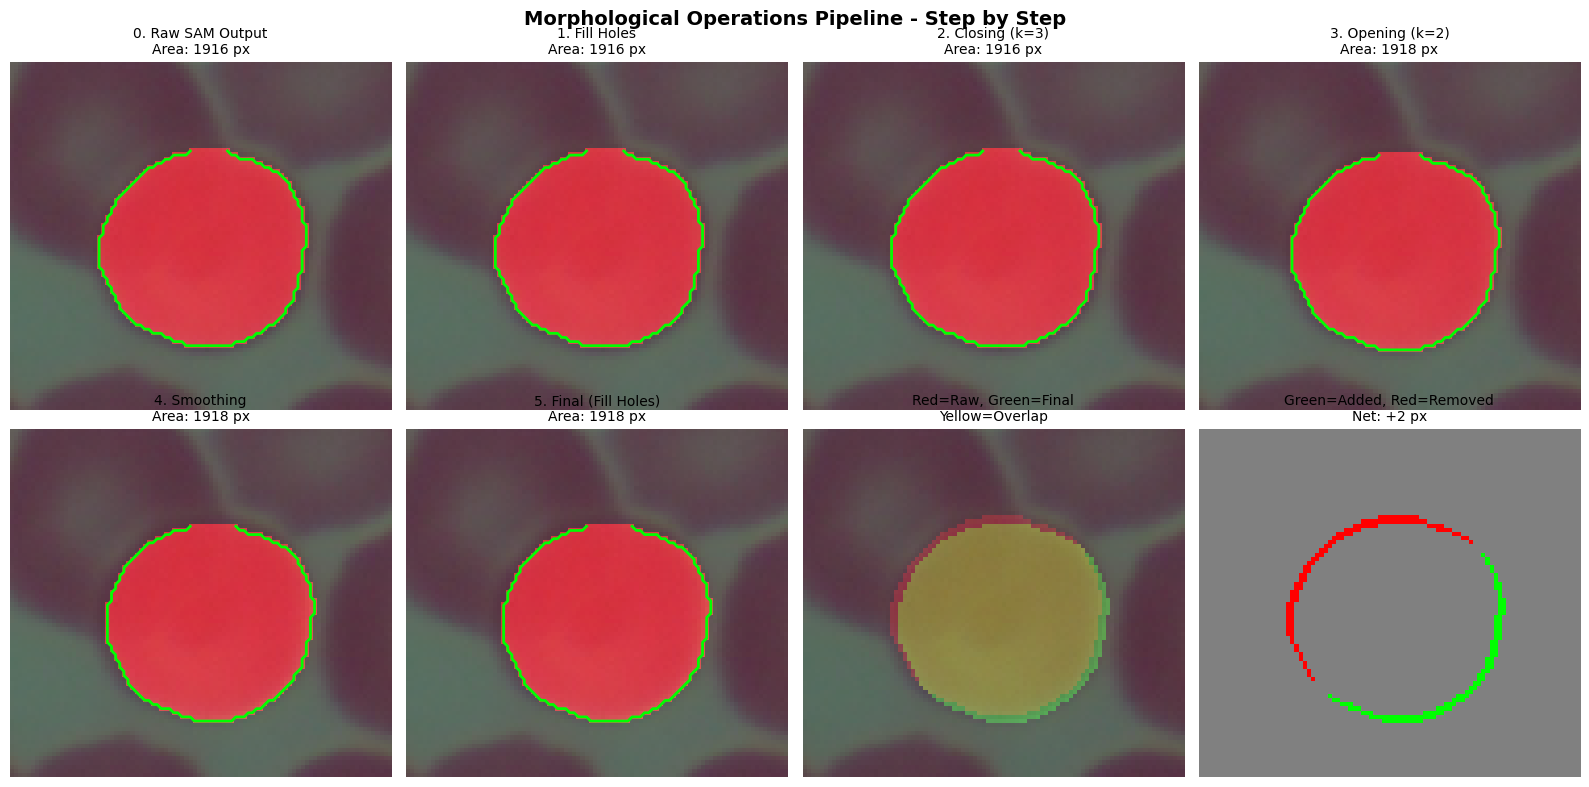


MORPHOLOGICAL OPERATIONS SUMMARY
Initial area: 1916 pixels
Final area:   1918 pixels
Change:       +2 pixels (+0.1%)

Operations applied:
  1. Fill Holes - Fills internal gaps in the cell
  2. Closing (k=3) - Connects nearby regions, smooths exterior boundaries
  3. Opening (k=2) - Removes small noise and protrusions
  4. Smoothing - Erode then dilate to smooth boundaries
  5. Final Fill - Ensures no remaining internal holes

[3/4] Running SAM segmentation with improved morphology...
  Processing 23 RBC boxes...
  ✓ Successfully generated 23 RBC masks
  Processing 2 WBC boxes...
  ✓ Successfully generated 2 WBC masks

[4/4] Performing morphological analysis...


/tmp/ipykernel_48/1468876958.py:176: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  filtered = morphology.remove_small_objects(labeled, min_size=min_area)



MORPHOLOGICAL ANALYSIS RESULTS

📍 Red Blood Cells (RBC):
  ├─ Detected Count: 23
  ├─ Segmented Count: 23
  ├─ Mean Area: 1372.7 ± 734.9 pixels
  ├─ Median Area: 1554.0 pixels
  ├─ Mean Circularity: 0.744 (0=line, 1=circle)
  └─ Mean Solidity: 0.952 (cell fullness)

📍 White Blood Cells (WBC):
  ├─ Detected Count: 2
  ├─ Segmented Count: 2
  ├─ Mean Area: 6159.5 ± 5.5 pixels
  ├─ Median Area: 6159.5 pixels
  ├─ Mean Circularity: 0.807
  └─ Mean Solidity: 0.954

✓ Analysis complete! Check the visualizations above.


In [35]:
def yolo_to_xyxy(image, bboxes_yolo):
    """Convert YOLO format to xyxy"""
    height, width = image.shape[:2]
    bboxes_xyxy = []
    
    for bbox in bboxes_yolo:
        x_center, y_center, w, h = bbox
        x1 = (x_center - w / 2) * width
        y1 = (y_center - h / 2) * height
        x2 = (x_center + w / 2) * width
        y2 = (y_center + h / 2) * height
        bboxes_xyxy.append([x1, y1, x2, y2])
    
    return np.array(bboxes_xyxy)

print("="*70)
print("TESTING IMPROVED SAM SEGMENTATION WITH MORPHOLOGICAL OPERATIONS")
print("="*70)

# Load YOLO model
yolo_model = YOLO('runs/detect/train/weights/best.pt')

# Load SAM
sam_segmenter = SAMSegmenter('sam_vit_h_4b8939.pth')

# Test on a sample image
test_images = glob.glob('datasets/blood_cells/test/images/*.png')
sample_image_path = test_images[0]

print(f"\nProcessing: {sample_image_path}")

# Load image
sample_image_paths = cv2.imread(sample_image_path)
image_rgb = cv2.cvtColor(sample_image_paths, cv2.COLOR_BGR2RGB)
print(f"Image shape: {image_rgb.shape}")

# YOLO prediction
print("\n[1/4] Running YOLO detection...")
yolo_results = yolo_model(image_rgb, verbose=False)
boxes = yolo_results[0].boxes

# Separate RBC and WBC boxes
rbc_boxes = []
wbc_boxes = []

for box in boxes:
    class_id = int(box.cls[0])
    xyxy = box.xyxy[0].cpu().numpy()
    
    if class_id == 0:
        rbc_boxes.append(xyxy)
    else:
        wbc_boxes.append(xyxy)

print(f"✓ Detected: {len(rbc_boxes)} RBCs, {len(wbc_boxes)} WBCs")

# Demonstrate morphological operations on first RBC
if len(rbc_boxes) > 0:
    print("\n[2/4] Demonstrating morphological operations on first RBC cell...")
    visualize_morphological_operations(image_rgb, rbc_boxes[0], sam_segmenter)

# SAM segmentation with improved morphological refinement
print("\n[3/4] Running SAM segmentation with improved morphology...")
rbc_masks, rbc_features = [], []
if rbc_boxes:
    print(f"  Processing {len(rbc_boxes)} RBC boxes...")
    rbc_masks, rbc_features = sam_segmenter.segment_with_boxes(
        image_rgb, np.array(rbc_boxes), refine=True
    )
    print(f"  ✓ Successfully generated {len(rbc_masks)} RBC masks")

wbc_masks, wbc_features = [], []
if wbc_boxes:
    print(f"  Processing {len(wbc_boxes)} WBC boxes...")
    wbc_masks, wbc_features = sam_segmenter.segment_with_boxes(
        image_rgb, np.array(wbc_boxes), refine=True
    )
    print(f"  ✓ Successfully generated {len(wbc_masks)} WBC masks")

# Morphological analysis
print("\n[4/4] Performing morphological analysis...")
analyzer = CellAnalyzer()
analysis_results = analyzer.analyze_image(
    image_rgb, rbc_masks, wbc_masks, separate_touching=True
)

print("\n" + "="*70)
print("MORPHOLOGICAL ANALYSIS RESULTS")
print("="*70)

if analysis_results['rbc']['statistics']:
    stats = analysis_results['rbc']['statistics']
    print(f"\n📍 Red Blood Cells (RBC):")
    print(f"  ├─ Detected Count: {len(rbc_boxes)}")
    print(f"  ├─ Segmented Count: {stats['count']}")
    print(f"  ├─ Mean Area: {stats['mean_area']:.1f} ± {stats['std_area']:.1f} pixels")
    print(f"  ├─ Median Area: {stats['median_area']:.1f} pixels")
    print(f"  ├─ Mean Circularity: {stats['mean_circularity']:.3f} (0=line, 1=circle)")
    print(f"  └─ Mean Solidity: {stats['mean_solidity']:.3f} (cell fullness)")

if analysis_results['wbc']['statistics']:
    stats = analysis_results['wbc']['statistics']
    print(f"\n📍 White Blood Cells (WBC):")
    print(f"  ├─ Detected Count: {len(wbc_boxes)}")
    print(f"  ├─ Segmented Count: {stats['count']}")
    print(f"  ├─ Mean Area: {stats['mean_area']:.1f} ± {stats['std_area']:.1f} pixels")
    print(f"  ├─ Median Area: {stats['median_area']:.1f} pixels")
    print(f"  ├─ Mean Circularity: {stats['mean_circularity']:.3f}")
    print(f"  └─ Mean Solidity: {stats['mean_solidity']:.3f}")

print("\n" + "="*70)
print("✓ Analysis complete! Check the visualizations above.")
print("="*70)


/tmp/ipykernel_48/3651569458.py:121: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_48/3651569458.py:121: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_48/3651569458.py:122: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig('improved_morphological_analysis.png', dpi=200, bbox_inches='tight')
/tmp/ipykernel_48/3651569458.py:122: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from current font.
  plt.savefig('improved_morphological_analysis.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9898 (\N{MEDIUM WHITE CIRCLE}) missing from current font.

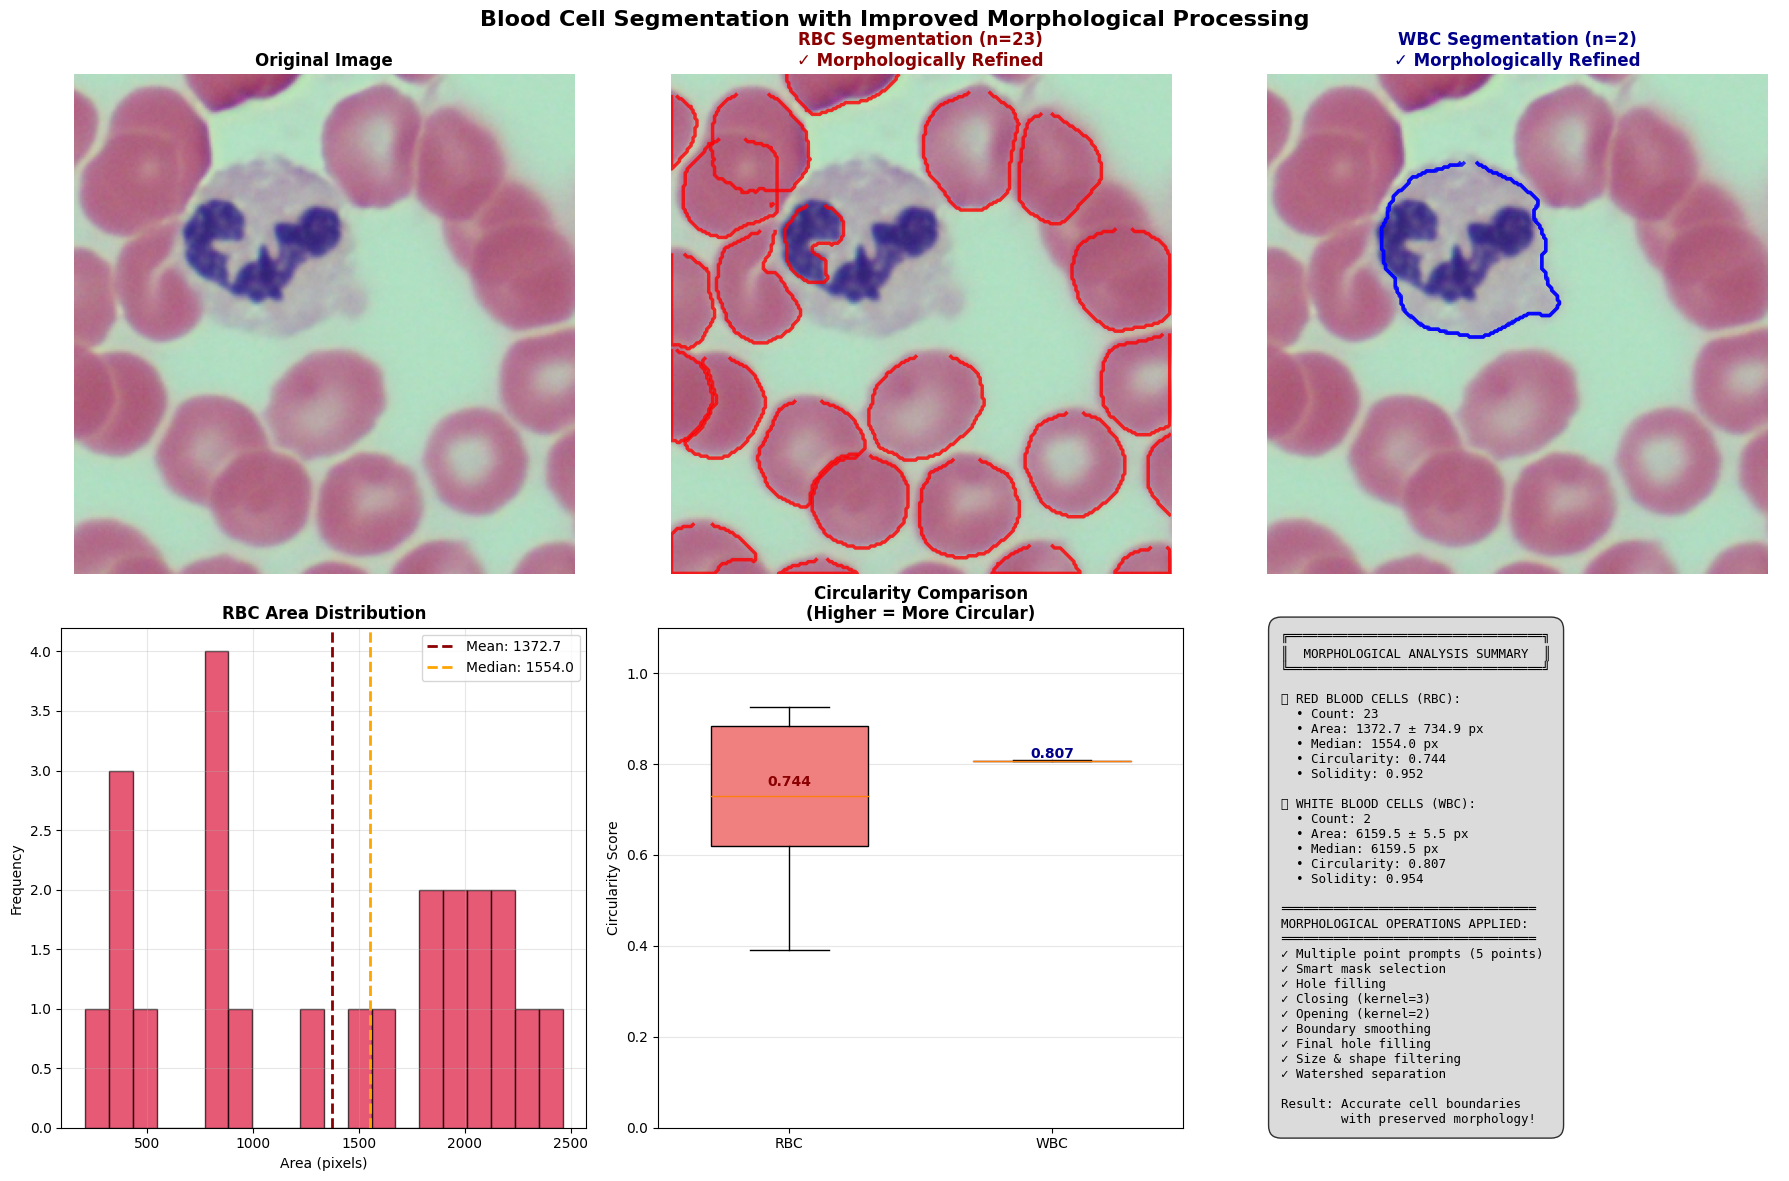


✓ Visualization saved as 'improved_morphological_analysis.png'
✓ RBC contours drawn: 24
✓ WBC contours drawn: 2


In [36]:
# Enhanced visualization with improved morphology
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# RBC segmentation with refined masks
axes[0, 1].imshow(image_rgb)
rbc_contour_count = 0
for mask in rbc_masks:
    # Ensure mask is proper format for findContours
    mask_display = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.astype(np.uint8)
    contours, _ = cv2.findContours(mask_display, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if len(contour) > 2:
            axes[0, 1].plot(contour[:, 0, 0], contour[:, 0, 1], 'r-', linewidth=2.5, alpha=0.8)
            rbc_contour_count += 1
axes[0, 1].set_title(f'RBC Segmentation (n={len(rbc_masks)})\n✓ Morphologically Refined', 
                     fontsize=12, fontweight='bold', color='darkred')
axes[0, 1].axis('off')

# WBC segmentation
axes[0, 2].imshow(image_rgb)
wbc_contour_count = 0
for mask in wbc_masks:
    mask_display = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.astype(np.uint8)
    contours, _ = cv2.findContours(mask_display, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if len(contour) > 2:
            axes[0, 2].plot(contour[:, 0, 0], contour[:, 0, 1], 'b-', linewidth=2.5, alpha=0.8)
            wbc_contour_count += 1
axes[0, 2].set_title(f'WBC Segmentation (n={len(wbc_masks)})\n✓ Morphologically Refined', 
                     fontsize=12, fontweight='bold', color='darkblue')
axes[0, 2].axis('off')

# RBC area distribution
if analysis_results['rbc']['features']:
    areas = [f['area'] for f in analysis_results['rbc']['features'] if f]
    axes[1, 0].hist(areas, bins=20, color='crimson', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(np.mean(areas), color='darkred', linestyle='--', linewidth=2, 
                       label=f'Mean: {np.mean(areas):.1f}')
    axes[1, 0].axvline(np.median(areas), color='orange', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(areas):.1f}')
    axes[1, 0].set_title('RBC Area Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Area (pixels)', fontsize=10)
    axes[1, 0].set_ylabel('Frequency', fontsize=10)
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)

# Circularity comparison
if analysis_results['rbc']['features'] and analysis_results['wbc']['features']:
    rbc_circ = [f['circularity'] for f in analysis_results['rbc']['features'] if f]
    wbc_circ = [f['circularity'] for f in analysis_results['wbc']['features'] if f]
    
    bp = axes[1, 1].boxplot([rbc_circ, wbc_circ], labels=['RBC', 'WBC'],
                            patch_artist=True, widths=0.6)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightblue')
    
    axes[1, 1].set_title('Circularity Comparison\n(Higher = More Circular)', 
                        fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Circularity Score', fontsize=10)
    axes[1, 1].set_ylim([0, 1.1])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Add mean values as text
    axes[1, 1].text(1, np.mean(rbc_circ), f'{np.mean(rbc_circ):.3f}', 
                   ha='center', va='bottom', fontweight='bold', color='darkred')
    axes[1, 1].text(2, np.mean(wbc_circ), f'{np.mean(wbc_circ):.3f}',
                   ha='center', va='bottom', fontweight='bold', color='darkblue')

# Statistics text with improved formatting
stats_text = "╔══════════════════════════════════╗\n"
stats_text += "║  MORPHOLOGICAL ANALYSIS SUMMARY  ║\n"
stats_text += "╚══════════════════════════════════╝\n\n"

if analysis_results['rbc']['statistics']:
    stats = analysis_results['rbc']['statistics']
    stats_text += "🔴 RED BLOOD CELLS (RBC):\n"
    stats_text += f"  • Count: {stats['count']}\n"
    stats_text += f"  • Area: {stats['mean_area']:.1f} ± {stats['std_area']:.1f} px\n"
    stats_text += f"  • Median: {stats['median_area']:.1f} px\n"
    stats_text += f"  • Circularity: {stats['mean_circularity']:.3f}\n"
    stats_text += f"  • Solidity: {stats['mean_solidity']:.3f}\n\n"

if analysis_results['wbc']['statistics']:
    stats = analysis_results['wbc']['statistics']
    stats_text += "⚪ WHITE BLOOD CELLS (WBC):\n"
    stats_text += f"  • Count: {stats['count']}\n"
    stats_text += f"  • Area: {stats['mean_area']:.1f} ± {stats['std_area']:.1f} px\n"
    stats_text += f"  • Median: {stats['median_area']:.1f} px\n"
    stats_text += f"  • Circularity: {stats['mean_circularity']:.3f}\n"
    stats_text += f"  • Solidity: {stats['mean_solidity']:.3f}\n\n"

stats_text += "═" * 34 + "\n"
stats_text += "MORPHOLOGICAL OPERATIONS APPLIED:\n"
stats_text += "═" * 34 + "\n"
stats_text += "✓ Multiple point prompts (5 points)\n"
stats_text += "✓ Smart mask selection\n"
stats_text += "✓ Hole filling\n"
stats_text += "✓ Closing (kernel=3)\n"
stats_text += "✓ Opening (kernel=2)\n"
stats_text += "✓ Boundary smoothing\n"
stats_text += "✓ Final hole filling\n"
stats_text += "✓ Size & shape filtering\n"
stats_text += "✓ Watershed separation\n\n"
stats_text += "Result: Accurate cell boundaries\n"
stats_text += "        with preserved morphology!"

axes[1, 2].text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
                verticalalignment='center', 
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8, pad=1))
axes[1, 2].axis('off')

plt.suptitle('Blood Cell Segmentation with Improved Morphological Processing', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('improved_morphological_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'improved_morphological_analysis.png'")
print(f"✓ RBC contours drawn: {rbc_contour_count}")
print(f"✓ WBC contours drawn: {wbc_contour_count}")



DEMONSTRATING CELL SEPARATION FOR RBC
Combined mask area: 30776 pixels
Cells before separation: 23
Cells after separation: 22
Additional cells found: -1


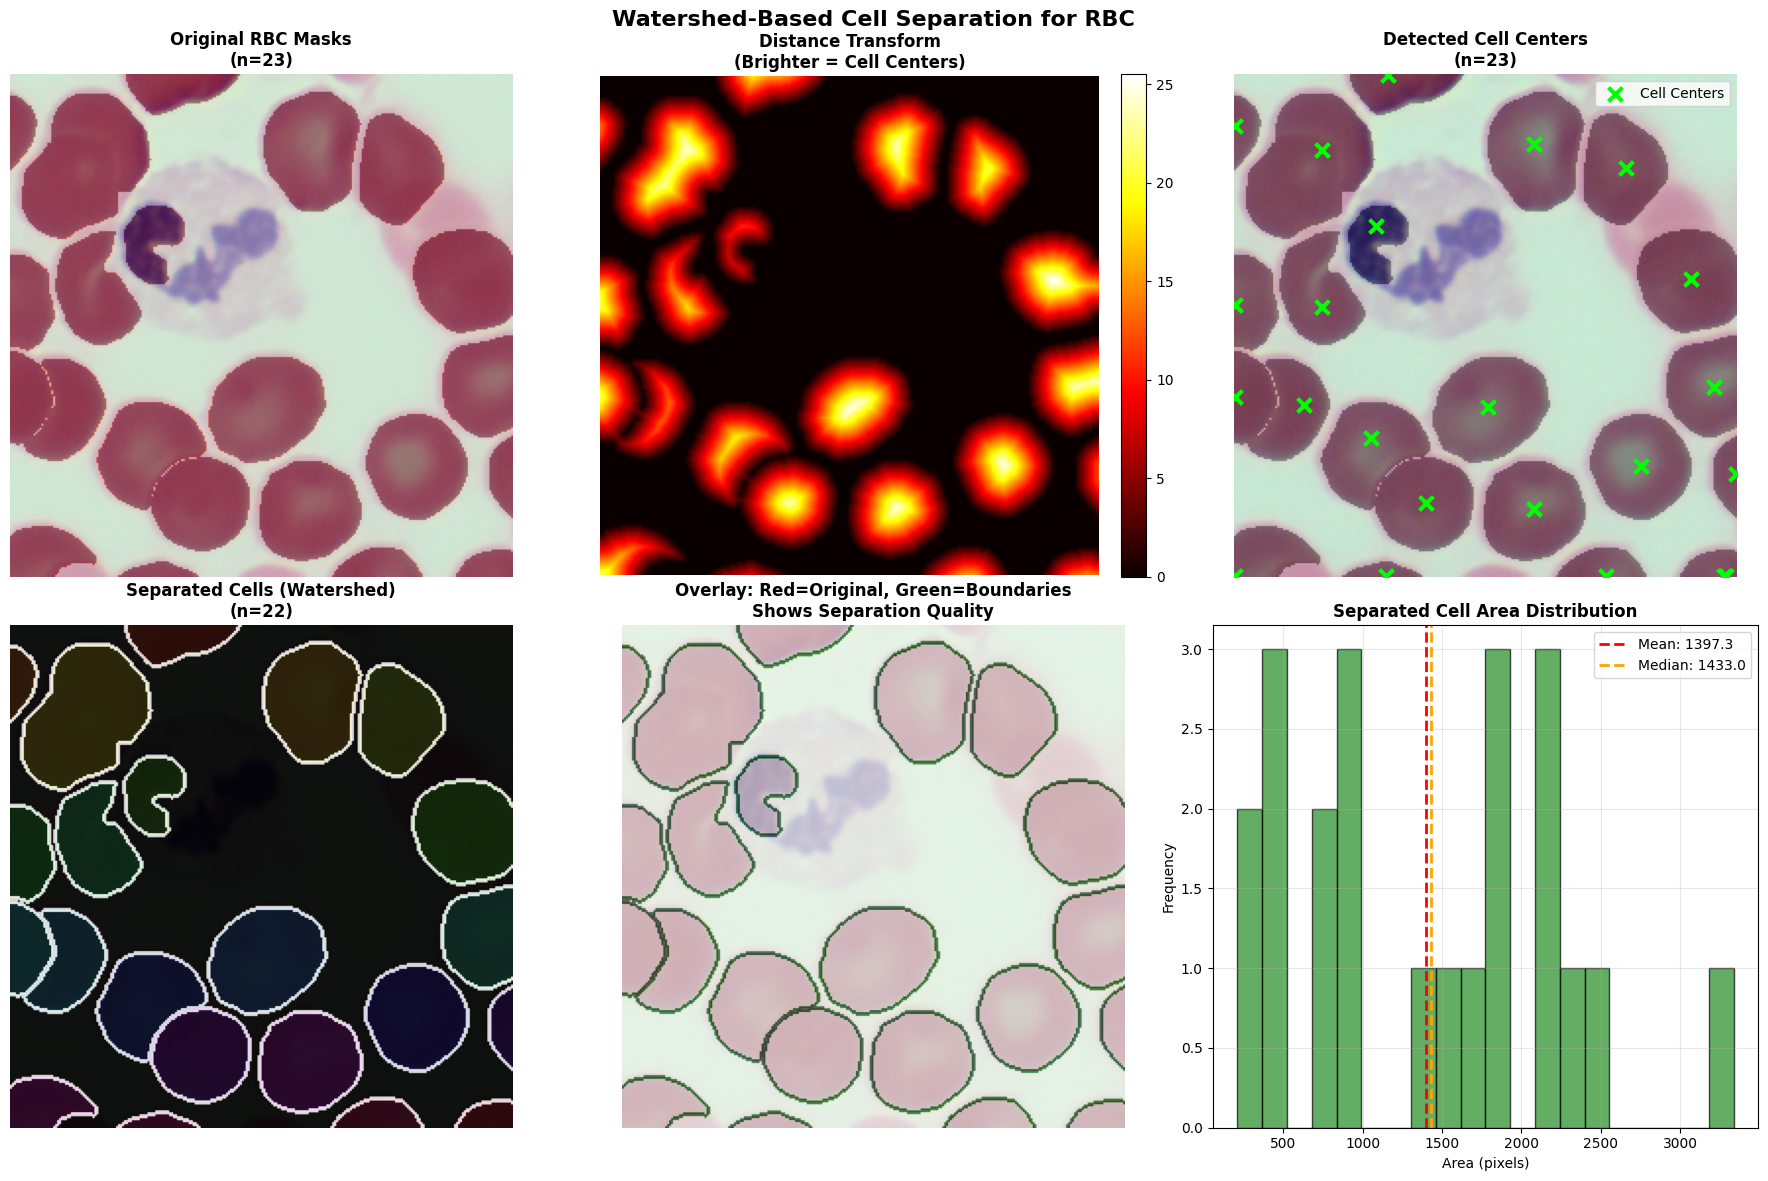


SEPARATION SUMMARY:
✓ Original cells detected: 23
✓ Cells after separation: 22
✓ Improvement: -1 cells
✓ Average cell area: 1397.3 ± 833.7 pixels
✓ Cell area range: 210 - 3336 pixels


In [37]:
# ============================================================================
# DEMONSTRATE WATERSHED CELL SEPARATION ON TOUCHING/OVERLAPPING CELLS
# ============================================================================

def demonstrate_cell_separation(image, masks, cell_type="RBC"):
    """
    Visualize watershed-based separation of touching cells
    """
    print(f"\n{'='*70}")
    print(f"DEMONSTRATING CELL SEPARATION FOR {cell_type}")
    print(f"{'='*70}")
    
    if len(masks) == 0:
        print(f"No {cell_type} masks to process")
        return
    
    # Combine all masks
    combined_mask = np.zeros_like(masks[0], dtype=np.uint8)
    for mask in masks:
        combined_mask = np.maximum(combined_mask, mask.astype(np.uint8))
    
    print(f"Combined mask area: {combined_mask.sum()} pixels")
    
    # Apply watershed separation
    morph = MorphologyProcessor()
    separated_labels = morph.separate_touching_cells(combined_mask, min_distance=5)
    
    num_cells_before = len(masks)
    num_cells_after = separated_labels.max()
    
    print(f"Cells before separation: {num_cells_before}")
    print(f"Cells after separation: {num_cells_after}")
    print(f"Additional cells found: {num_cells_after - num_cells_before}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Original image with masks
    axes[0, 0].imshow(image)
    axes[0, 0].imshow(combined_mask, alpha=0.4, cmap='Reds')
    axes[0, 0].set_title(f'Original {cell_type} Masks\n(n={num_cells_before})', 
                         fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # 2. Distance transform
    distance = ndimage.distance_transform_edt(combined_mask)
    im1 = axes[0, 1].imshow(distance, cmap='hot')
    axes[0, 1].set_title('Distance Transform\n(Brighter = Cell Centers)', 
                         fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # 3. Local maxima (markers)
    distance_smooth = ndimage.gaussian_filter(distance, sigma=1)
    local_max = morphology.h_maxima(distance_smooth, h=distance_smooth.max() * 0.25)
    
    axes[0, 2].imshow(image)
    axes[0, 2].imshow(combined_mask, alpha=0.3, cmap='Greys')
    
    # Show markers as points
    markers_coords = np.where(local_max)
    axes[0, 2].scatter(markers_coords[1], markers_coords[0], c='lime', 
                      s=100, marker='x', linewidths=3, label='Cell Centers')
    axes[0, 2].set_title(f'Detected Cell Centers\n(n={len(markers_coords[0])})', 
                         fontsize=12, fontweight='bold')
    axes[0, 2].legend(loc='upper right')
    axes[0, 2].axis('off')
    
    # 4. Watershed boundaries
    axes[1, 0].imshow(image)
    
    # Show each separated cell in different color
    colored_labels = np.zeros((*separated_labels.shape, 3), dtype=np.uint8)
    for label_id in range(1, separated_labels.max() + 1):
        mask_region = (separated_labels == label_id)
        color = plt.cm.hsv(label_id / separated_labels.max())[:3]
        colored_labels[mask_region] = [int(c * 255) for c in color]
    
    axes[1, 0].imshow(colored_labels, alpha=0.6)
    
    # Draw watershed boundaries
    boundaries = segmentation.find_boundaries(separated_labels, mode='thick')
    axes[1, 0].imshow(boundaries, alpha=0.8, cmap='Greys_r')
    
    axes[1, 0].set_title(f'Separated Cells (Watershed)\n(n={num_cells_after})', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # 5. Before vs After comparison
    axes[1, 1].imshow(image)
    
    # Original masks in red
    axes[1, 1].imshow(combined_mask, alpha=0.3, cmap='Reds')
    
    # Separated boundaries in green
    axes[1, 1].imshow(boundaries, alpha=0.6, cmap='Greens')
    
    axes[1, 1].set_title('Overlay: Red=Original, Green=Boundaries\nShows Separation Quality', 
                         fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    # 6. Cell size distribution
    cell_areas = []
    for label_id in range(1, separated_labels.max() + 1):
        area = (separated_labels == label_id).sum()
        cell_areas.append(area)
    
    if cell_areas:
        axes[1, 2].hist(cell_areas, bins=20, color='forestgreen', alpha=0.7, edgecolor='black')
        axes[1, 2].axvline(np.mean(cell_areas), color='red', linestyle='--', 
                          linewidth=2, label=f'Mean: {np.mean(cell_areas):.1f}')
        axes[1, 2].axvline(np.median(cell_areas), color='orange', linestyle='--', 
                          linewidth=2, label=f'Median: {np.median(cell_areas):.1f}')
        axes[1, 2].set_title(f'Separated Cell Area Distribution', 
                            fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Area (pixels)', fontsize=10)
        axes[1, 2].set_ylabel('Frequency', fontsize=10)
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Watershed-Based Cell Separation for {cell_type}', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'{cell_type.lower()}_cell_separation.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{'='*70}")
    print("SEPARATION SUMMARY:")
    print(f"{'='*70}")
    print(f"✓ Original cells detected: {num_cells_before}")
    print(f"✓ Cells after separation: {num_cells_after}")
    print(f"✓ Improvement: {num_cells_after - num_cells_before:+d} cells")
    print(f"✓ Average cell area: {np.mean(cell_areas):.1f} ± {np.std(cell_areas):.1f} pixels")
    print(f"✓ Cell area range: {min(cell_areas):.0f} - {max(cell_areas):.0f} pixels")
    
    return separated_labels, cell_areas

# Run demonstration on RBC masks
if len(rbc_masks) > 0:
    separated_rbc, rbc_areas = demonstrate_cell_separation(image_rgb, rbc_masks, "RBC")
else:
    print("No RBC masks available for separation demonstration")


In [38]:
# ============================================================================
# COMPREHENSIVE MORPHOLOGY VISUALIZATION
# Shows: Original -> YOLO Boxes -> Raw SAM -> After Morphology -> Final Result
# ============================================================================

def visualize_complete_pipeline(image_path, yolo_model, sam_segmenter, save_name="pipeline_result"):
    """Complete visualization of the entire segmentation pipeline"""
    
    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print(f"Processing: {os.path.basename(image_path)}")
    print(f"Image shape: {img_rgb.shape}")
    
    # YOLO detection
    yolo_results = yolo_model(img_rgb, verbose=False)
    boxes = yolo_results[0].boxes
    
    # Separate by class
    rbc_boxes, wbc_boxes = [], []
    for box in boxes:
        class_id = int(box.cls[0])
        xyxy = box.xyxy[0].cpu().numpy()
        if class_id == 0:
            rbc_boxes.append(xyxy)
        else:
            wbc_boxes.append(xyxy)
    
    print(f"Detected: {len(rbc_boxes)} RBCs, {len(wbc_boxes)} WBCs")
    
    # SAM segmentation
    rbc_masks, wbc_masks = [], []
    rbc_masks_raw, wbc_masks_raw = [], []
    
    if rbc_boxes:
        rbc_masks, _ = sam_segmenter.segment_with_boxes(
            img_rgb, np.array(rbc_boxes), refine=True, use_point_prompts=True
        )
        # Get raw masks (no refinement)
        rbc_masks_raw, _ = sam_segmenter.segment_with_boxes(
            img_rgb, np.array(rbc_boxes), refine=False, use_point_prompts=True
        )
    
    if wbc_boxes:
        wbc_masks, _ = sam_segmenter.segment_with_boxes(
            img_rgb, np.array(wbc_boxes), refine=True, use_point_prompts=True
        )
        wbc_masks_raw, _ = sam_segmenter.segment_with_boxes(
            img_rgb, np.array(wbc_boxes), refine=False, use_point_prompts=True
        )
    
    print(f"Generated: {len(rbc_masks)} RBC masks, {len(wbc_masks)} WBC masks")
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Row 1: Overview
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(img_rgb)
    ax1.set_title('1. Original Image', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(img_rgb)
    for box in rbc_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='red', facecolor='none', label='RBC')
    for box in wbc_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='blue', facecolor='none', label='WBC')
        ax2.add_patch(rect)
    ax2.set_title(f'2. YOLO Detection\n{len(rbc_boxes)} RBCs, {len(wbc_boxes)} WBCs', 
                  fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(img_rgb)
    for mask in rbc_masks_raw:
        contours, _ = cv2.findContours((mask * 255).astype(np.uint8), 
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if len(contour) > 2:
                ax3.plot(contour[:, 0, 0], contour[:, 0, 1], 'r-', linewidth=1.5, alpha=0.7)
    for mask in wbc_masks_raw:
        contours, _ = cv2.findContours((mask * 255).astype(np.uint8), 
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if len(contour) > 2:
                ax3.plot(contour[:, 0, 0], contour[:, 0, 1], 'b-', linewidth=1.5, alpha=0.7)
    ax3.set_title('3. Raw SAM Output\n(Before Morphology)', fontsize=12, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.imshow(img_rgb)
    for mask in rbc_masks:
        contours, _ = cv2.findContours((mask * 255).astype(np.uint8), 
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if len(contour) > 2:
                ax4.plot(contour[:, 0, 0], contour[:, 0, 1], 'r-', linewidth=2)
    for mask in wbc_masks:
        contours, _ = cv2.findContours((mask * 255).astype(np.uint8), 
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if len(contour) > 2:
                ax4.plot(contour[:, 0, 0], contour[:, 0, 1], 'b-', linewidth=2)
    ax4.set_title('4. After Morphology\n(Final Result)', fontsize=12, fontweight='bold')
    ax4.axis('off')
    
    # Row 2: RBC Details
    ax5 = fig.add_subplot(gs[1, 0])
    rbc_overlay = img_rgb.copy()
    for mask in rbc_masks_raw:
        rbc_overlay[mask > 0] = [255, 100, 100]  # Red tint
    ax5.imshow(rbc_overlay)
    ax5.set_title(f'RBC Raw Masks\n(n={len(rbc_masks_raw)})', fontsize=11)
    ax5.axis('off')
    
    ax6 = fig.add_subplot(gs[1, 1])
    rbc_refined = img_rgb.copy()
    for mask in rbc_masks:
        rbc_refined[mask > 0] = [255, 50, 50]  # Darker red
    ax6.imshow(rbc_refined)
    ax6.set_title(f'RBC Refined Masks\n(n={len(rbc_masks)})', fontsize=11)
    ax6.axis('off')
    
    # RBC mask comparison
    if len(rbc_masks) > 0:
        ax7 = fig.add_subplot(gs[1, 2])
        ax7.imshow(rbc_masks_raw[0] if len(rbc_masks_raw) > 0 else np.zeros_like(img_rgb[:,:,0]), 
                   cmap='Reds', vmin=0, vmax=1)
        ax7.set_title('Sample RBC\nBefore Morphology', fontsize=11)
        ax7.axis('off')
        
        ax8 = fig.add_subplot(gs[1, 3])
        ax8.imshow(rbc_masks[0], cmap='Reds', vmin=0, vmax=1)
        ax8.set_title('Sample RBC\nAfter Morphology', fontsize=11)
        ax8.axis('off')
    
    # Row 3: WBC Details
    ax9 = fig.add_subplot(gs[2, 0])
    wbc_overlay = img_rgb.copy()
    for mask in wbc_masks_raw:
        wbc_overlay[mask > 0] = [100, 100, 255]  # Blue tint
    ax9.imshow(wbc_overlay)
    ax9.set_title(f'WBC Raw Masks\n(n={len(wbc_masks_raw)})', fontsize=11)
    ax9.axis('off')
    
    ax10 = fig.add_subplot(gs[2, 1])
    wbc_refined = img_rgb.copy()
    for mask in wbc_masks:
        wbc_refined[mask > 0] = [50, 50, 255]  # Darker blue
    ax10.imshow(wbc_refined)
    ax10.set_title(f'WBC Refined Masks\n(n={len(wbc_masks)})', fontsize=11)
    ax10.axis('off')
    
    # WBC mask comparison
    if len(wbc_masks) > 0:
        ax11 = fig.add_subplot(gs[2, 2])
        ax11.imshow(wbc_masks_raw[0] if len(wbc_masks_raw) > 0 else np.zeros_like(img_rgb[:,:,0]), 
                    cmap='Blues', vmin=0, vmax=1)
        ax11.set_title('Sample WBC\nBefore Morphology', fontsize=11)
        ax11.axis('off')
        
        ax12 = fig.add_subplot(gs[2, 3])
        ax12.imshow(wbc_masks[0], cmap='Blues', vmin=0, vmax=1)
        ax12.set_title('Sample WBC\nAfter Morphology', fontsize=11)
        ax12.axis('off')
    
    plt.suptitle(f'Complete Segmentation Pipeline: {os.path.basename(image_path)}',
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Save
    plt.savefig(f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("SEGMENTATION STATISTICS")
    print("="*60)
    print(f"RBC - Detected: {len(rbc_boxes)}, Segmented: {len(rbc_masks)}")
    if len(rbc_masks) > 0:
        rbc_areas = [mask.sum() for mask in rbc_masks]
        print(f"  Mean area: {np.mean(rbc_areas):.1f} ± {np.std(rbc_areas):.1f} pixels")
    
    print(f"\nWBC - Detected: {len(wbc_boxes)}, Segmented: {len(wbc_masks)}")
    if len(wbc_masks) > 0:
        wbc_areas = [mask.sum() for mask in wbc_masks]
        print(f"  Mean area: {np.mean(wbc_areas):.1f} ± {np.std(wbc_areas):.1f} pixels")
    print("="*60)
    
    return rbc_masks, wbc_masks

print("Complete pipeline visualization function loaded!")
print("Usage: visualize_complete_pipeline(image_path, yolo_model, sam_segmenter)")

Complete pipeline visualization function loaded!
Usage: visualize_complete_pipeline(image_path, yolo_model, sam_segmenter)


Processing: image-120.png
Image shape: (256, 256, 3)
Detected: 28 RBCs, 1 WBCs
Generated: 28 RBC masks, 1 WBC masks


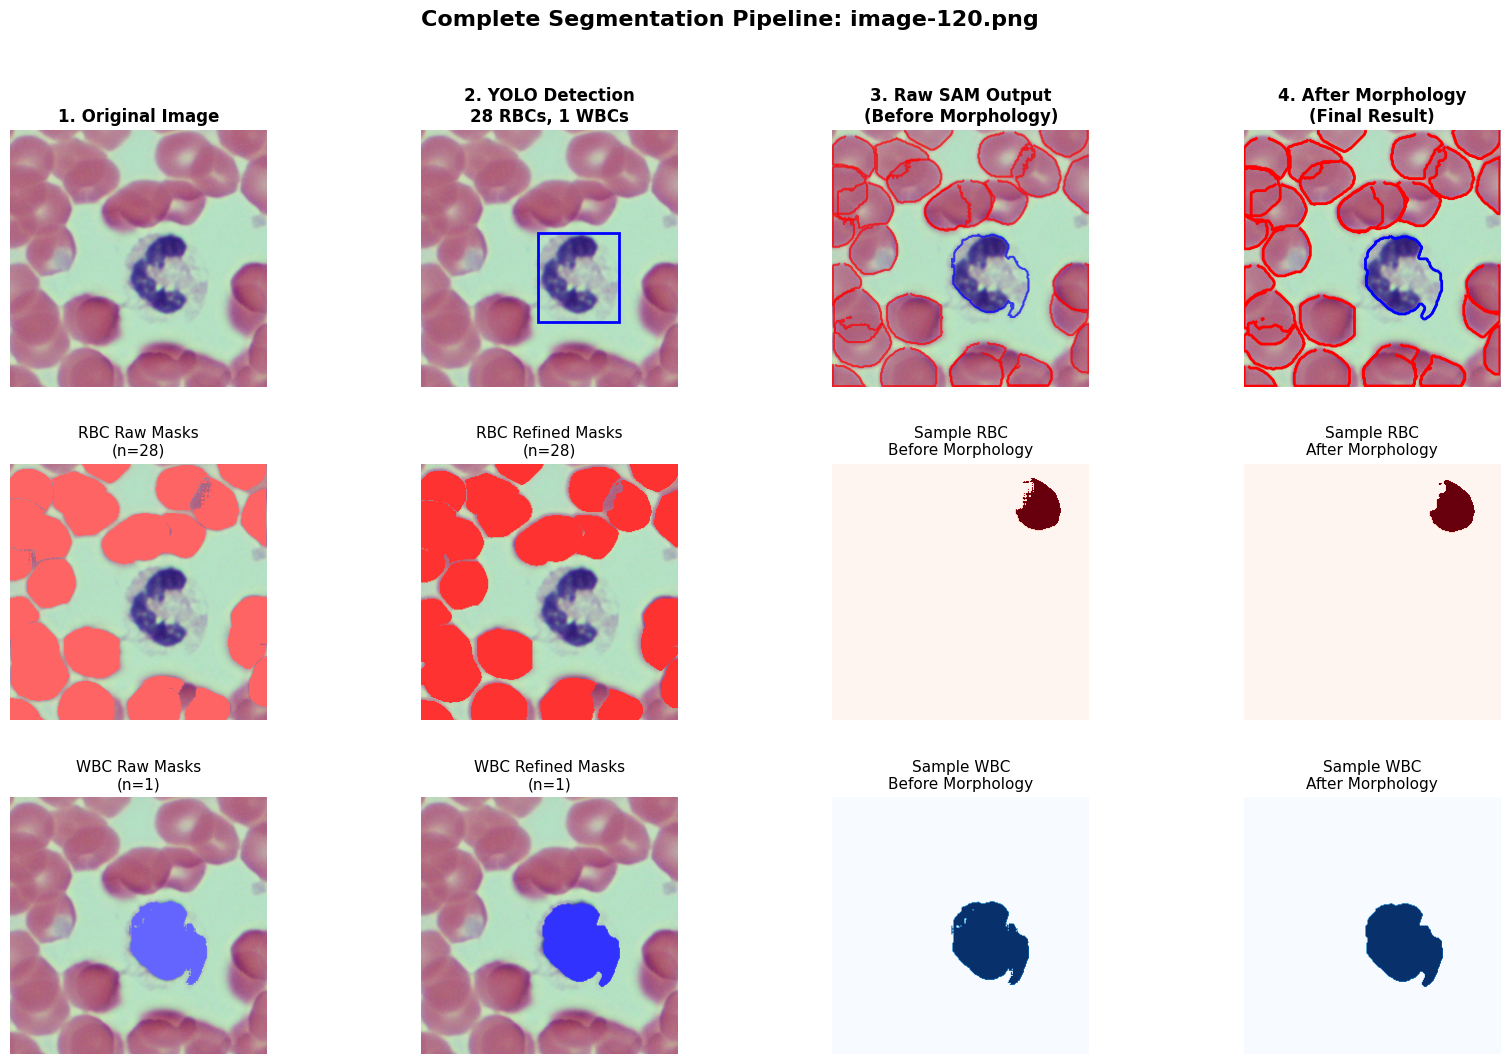


SEGMENTATION STATISTICS
RBC - Detected: 28, Segmented: 28
  Mean area: 1402.5 ± 543.0 pixels

WBC - Detected: 1, Segmented: 1
  Mean area: 4550.0 ± 0.0 pixels


([array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],


In [39]:
visualize_complete_pipeline("/kaggle/input/blood-cell-detection-dataset/images/image-120.png", yolo_model, sam_segmenter)

In [41]:
# ============================================================================
# UTILITIES: Adaptive & Edge-Guided Refinement + Quality Metrics
# ============================================================================
import cv2
import numpy as np
from skimage import morphology, feature
from scipy import ndimage

def adaptive_refine_mask(mask: np.ndarray, area: int) -> np.ndarray:
    """Adapt morphological kernel sizes based on mask area.
    Small cells -> preserve detail (tiny kernels)
    Large cells -> smooth more (larger closing/opening)
    """
    m = (mask > 0).astype(np.uint8)
    if area < 800:       # very small cell
        k_close, k_open = 2, 0  # skip opening
    elif area < 2500:    # medium
        k_close, k_open = 3, 2
    elif area < 7000:    # large
        k_close, k_open = 5, 3
    else:                # very large / WBC cluster
        k_close, k_open = 7, 3
    # Closing
    if k_close > 0:
        kernel_c = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_close, k_close))
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel_c)
    # Opening (optional)
    if k_open > 0:
        kernel_o = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_open, k_open))
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel_o)
    # Final hole fill
    m = ndimage.binary_fill_holes(m).astype(np.uint8)
    return m

def edge_guided_refine(image_rgb: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Refine mask boundary using Canny edges inside an expanded mask ROI.
    Tightens boundaries & removes leakage beyond strong edges.
    """
    m = (mask > 0).astype(np.uint8)
    # ROI
    ys, xs = np.where(m)
    if len(xs) == 0:
        return m
    y1, y2 = max(0, ys.min()-5), min(image_rgb.shape[0], ys.max()+5)
    x1, x2 = max(0, xs.min()-5), min(image_rgb.shape[1], xs.max()+5)
    roi_img = cv2.cvtColor(image_rgb[y1:y2, x1:x2], cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(roi_img, 50, 120)
    # Dilate edges to build a boundary band
    edges_d = cv2.dilate(edges, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)), iterations=1)
    roi_mask = m[y1:y2, x1:x2]
    # Keep mask pixels that are either well inside or close to edges band
    dist = ndimage.distance_transform_edt(roi_mask == 0)
    interior = dist > 3  # interior criterion
    refined_roi = ((roi_mask > 0) & (interior | (edges_d > 0))).astype(np.uint8)
    # Light smoothing
    refined_roi = cv2.morphologyEx(refined_roi, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)))
    # Reinsert
    new_mask = np.zeros_like(m)
    new_mask[y1:y2, x1:x2] = refined_roi
    return new_mask

def compute_quality_metrics(mask: np.ndarray) -> dict:
    """Compute shape-based quality metrics for a single binary mask."""
    m = (mask > 0).astype(np.uint8)
    area = int(m.sum())
    if area == 0:
        return {"area":0,"circularity":0,"solidity":0,"smoothness":0}
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"area":area,"circularity":0,"solidity":0,"smoothness":0}
    cnt = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(cnt, True)
    circularity = (4*np.pi*area)/(perimeter**2) if perimeter>0 else 0
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area/hull_area if hull_area>0 else 0
    # Smoothness (lower perimeter-normalized irregularity -> higher smoothness)
    smoothness = circularity * solidity
    return {"area":area,"circularity":circularity,"solidity":solidity,"smoothness":smoothness}

print("Adaptive & edge-guided refinement utilities loaded.")

Adaptive & edge-guided refinement utilities loaded.


In [42]:
# ============================================================================
# ENHANCED BATCH PROCESSING: Process and Save All Test Images with Quality Checks
# Further improved with adaptive & edge-guided refinement and quality metrics
# ============================================================================

output_dir = 'all_segmented_results_enhanced'
os.makedirs(output_dir, exist_ok=True)

# Configuration flags
CONF_THRESH = 0.5
USE_EDGE_GUIDED = True
USE_ADAPTIVE_REFINEMENT = True
SAMPLE_VIS_LIMIT = 3  # number of sample images to store side-by-side diagnostics

# Statistics tracking
batch_stats = {
    'rbc': {'counts': [], 'areas': [], 'circularities': [], 'solidities': [], 'smoothness': []},
    'wbc': {'counts': [], 'areas': [], 'circularities': [], 'solidities': [], 'smoothness': []},
    'processing_times': [],
    'quality_failures': 0,
    'samples': []  # store sample diagnostics
}

print("="*90)
print(f"🔬 ADVANCED BATCH PROCESSING: {len(test_images)} TEST IMAGES")
print("="*90)
print("\nPipeline Stages:")
print("  1. YOLO detection (confidence filter)")
print("  2. SAM segmentation (multi-point prompts)")
print("  3. Morphological base refinement (existing pipeline)")
print("  4. Adaptive morphology (area-based kernels)")
print("  5. Edge-guided boundary tightening (Canny-assisted)")
print("  6. Quality metrics computation (shape-based)")
print("  7. Visualization + aggregated statistics")
print("\n" + "="*90 + "\n")

import time
from tqdm import tqdm

for idx, test_img_path in enumerate(tqdm(test_images, desc="Processing images")):
    start_time = time.time()
    try:
        img_name = os.path.basename(test_img_path).replace('.png', '')
        img = cv2.imread(test_img_path)
        if img is None:
            print(f"⚠️ Failed to load image: {img_name}")
            batch_stats['quality_failures'] += 1
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # YOLO detection
        yolo_results = yolo_model(img_rgb, verbose=False)
        boxes = yolo_results[0].boxes
        rbc_boxes, wbc_boxes = [], []
        for box in boxes:
            conf = float(box.conf[0])
            if conf < CONF_THRESH:
                continue
            cls_id = int(box.cls[0])
            xyxy = box.xyxy[0].cpu().numpy()
            if cls_id == 0:
                rbc_boxes.append(xyxy)
            else:
                wbc_boxes.append(xyxy)

        # Base SAM segmentation (already includes morphological refinement)
        rbc_masks, rbc_features = [], []
        if rbc_boxes:
            rbc_masks, rbc_features = sam_segmenter.segment_with_boxes(
                img_rgb, np.array(rbc_boxes), refine=True, use_point_prompts=True
            )
        wbc_masks, wbc_features = [], []
        if wbc_boxes:
            wbc_masks, wbc_features = sam_segmenter.segment_with_boxes(
                img_rgb, np.array(wbc_boxes), refine=True, use_point_prompts=True
            )

        # Secondary adaptive + edge-guided refinement
        def secondary_refine(mask_list, feature_list, cell_type):
            refined_list = []
            refined_features = []
            for m, feat in zip(mask_list, feature_list):
                if feat is None:
                    continue
                area = feat['area']
                # Adaptive
                m2 = adaptive_refine_mask(m, area) if USE_ADAPTIVE_REFINEMENT else m
                # Edge-guided
                m3 = edge_guided_refine(img_rgb, m2) if USE_EDGE_GUIDED else m2
                # Preserve largest connected component to avoid fragmentation
                labeled = ndimage.label(m3)[0]
                if labeled.max() > 1:
                    sizes = [(l, (labeled==l).sum()) for l in range(1, labeled.max()+1)]
                    best_label = max(sizes, key=lambda x: x[1])[0]
                    m3 = (labeled == best_label).astype(np.uint8)
                # Recompute quality metrics
                q = compute_quality_metrics(m3)
                refined_list.append(m3)
                # Merge original feature dict with quality metrics
                merged_feat = dict(feat)
                merged_feat.update({
                    'adaptive_area': q['area'],
                    'adaptive_circularity': q['circularity'],
                    'adaptive_solidity': q['solidity'],
                    'smoothness': q['smoothness']
                })
                refined_features.append(merged_feat)
            return refined_list, refined_features

        rbc_masks_refined, rbc_features_refined = secondary_refine(rbc_masks, rbc_features, 'RBC')
        wbc_masks_refined, wbc_features_refined = secondary_refine(wbc_masks, wbc_features, 'WBC')

        # Quality filtering (second pass) based on refined metrics
        def quality_filter(mask_list, feature_list, cell_type):
            final_masks, final_feats = [] , []
            for m, f in zip(mask_list, feature_list):
                area = f['adaptive_area']
                circ = f['adaptive_circularity']
                sol = f['adaptive_solidity']
                smooth = f['smoothness']
                if cell_type == 'RBC':
                    if 60 < area < 9000 and circ > 0.35 and sol > 0.70 and smooth > 0.20:
                        final_masks.append(m)
                        final_feats.append(f)
                else:  # WBC
                    if 250 < area < 20000 and circ > 0.25 and sol > 0.55 and smooth > 0.15:
                        final_masks.append(m)
                        final_feats.append(f)
            return final_masks, final_feats

        rbc_masks_final, rbc_features_final = quality_filter(rbc_masks_refined, rbc_features_refined, 'RBC')
        wbc_masks_final, wbc_features_final = quality_filter(wbc_masks_refined, wbc_features_refined, 'WBC')

        # Collect statistics
        def accumulate(feats, key):
            if feats:
                batch_stats[key]['counts'].append(len(feats))
                batch_stats[key]['areas'].extend([f['adaptive_area'] for f in feats])
                batch_stats[key]['circularities'].extend([f['adaptive_circularity'] for f in feats])
                batch_stats[key]['solidities'].extend([f['adaptive_solidity'] for f in feats])
                batch_stats[key]['smoothness'].extend([f['smoothness'] for f in feats])
            else:
                batch_stats[key]['counts'].append(0)
        accumulate(rbc_features_final, 'rbc')
        accumulate(wbc_features_final, 'wbc')

        # Store sample diagnostics
        if len(batch_stats['samples']) < SAMPLE_VIS_LIMIT:
            batch_stats['samples'].append({
                'image_name': img_name,
                'original_rgb': img_rgb,
                'rbc_initial': rbc_masks[:4],
                'rbc_final': rbc_masks_final[:4],
                'wbc_initial': wbc_masks[:4],
                'wbc_final': wbc_masks_final[:4]
            })

        # Visualization panel
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes[0,0].imshow(img_rgb); axes[0,0].set_title('Original'); axes[0,0].axis('off')

        def draw_contours(ax, masks, color):
            ax.imshow(img_rgb)
            for m in masks:
                disp = (m*255).astype(np.uint8)
                cs, _ = cv2.findContours(disp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                for c in cs:
                    if len(c)>2:
                        ax.plot(c[:,0,0], c[:,0,1], color+'-', linewidth=2, alpha=0.8)

        axes[0,1].set_title(f'RBC Final (n={len(rbc_masks_final)})'); draw_contours(axes[0,1], rbc_masks_final,'r'); axes[0,1].axis('off')
        axes[0,2].set_title(f'WBC Final (n={len(wbc_masks_final)})'); draw_contours(axes[0,2], wbc_masks_final,'b'); axes[0,2].axis('off')

        # Overlay
        overlay = np.zeros_like(img_rgb)
        for m in rbc_masks_final: overlay[:,:,0] = np.maximum(overlay[:,:,0], m*255)
        for m in wbc_masks_final: overlay[:,:,2] = np.maximum(overlay[:,:,2], m*255)
        axes[1,0].imshow(img_rgb); axes[1,0].imshow(overlay, alpha=0.45); axes[1,0].set_title('Overlay (Red=RBC Blue=WBC)'); axes[1,0].axis('off')

        # Quality text
        def fmt(key):
            if batch_stats[key]['counts']:
                return (np.mean(batch_stats[key]['areas']), np.mean(batch_stats[key]['circularities']), np.mean(batch_stats[key]['solidities']), np.mean(batch_stats[key]['smoothness']))
            return (0,0,0,0)
        r_mean_area, r_mean_circ, r_mean_sol, r_mean_smooth = fmt('rbc')
        w_mean_area, w_mean_circ, w_mean_sol, w_mean_smooth = fmt('wbc')
        txt = f"IMAGE: {img_name}\n" \
              f"RBC Count: {len(rbc_masks_final)}  WBC Count: {len(wbc_masks_final)}\n" \
              f"RBC Mean (Area,Circ,Sol,Smooth): {r_mean_area:.0f},{r_mean_circ:.2f},{r_mean_sol:.2f},{r_mean_smooth:.2f}\n" \
              f"WBC Mean (Area,Circ,Sol,Smooth): {w_mean_area:.0f},{w_mean_circ:.2f},{w_mean_sol:.2f},{w_mean_smooth:.2f}\n" \
              f"Adaptive: {USE_ADAPTIVE_REFINEMENT}  EdgeGuided: {USE_EDGE_GUIDED}\n"
        axes[1,1].text(0.05,0.5,txt,fontsize=9,family='monospace',bbox=dict(boxstyle='round',facecolor='lightgray',alpha=0.85)); axes[1,1].axis('off')

        # Comparison small multiples (first RBC mask if exists)
        axes[1,2].set_title('Sample RBC Evolution', fontsize=11)
        axes[1,2].axis('off')
        if rbc_masks and rbc_masks_final:
            base = rbc_masks[0]; finalm = rbc_masks_final[0]
            diff = finalm.astype(int) - base.astype(int)
            comp = np.zeros((base.shape[0], base.shape[1],3),dtype=np.uint8)
            comp[base>0] = [255,0,0]      # red original
            comp[finalm>0] = [0,255,0]    # green final
            comp[(base>0)&(finalm>0)] = [255,255,0] # overlap yellow
            axes[1,2].imshow(comp)
        plt.suptitle(f'Advanced Cell Segmentation - Image {idx+1}/{len(test_images)}', fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/{img_name}_advanced.png', dpi=150, bbox_inches='tight')
        plt.close()

        processing_time = time.time() - start_time
        batch_stats['processing_times'].append(processing_time)

    except Exception as e:
        print(f"\n❌ Error processing {img_name}: {str(e)}")
        batch_stats['quality_failures'] += 1
        continue

# Aggregate statistics
print("\n" + "="*90)
print("📊 ADVANCED BATCH PROCESSING COMPLETE - SUMMARY")
print("="*90)
print(f"Processed: {len(test_images)-batch_stats['quality_failures']}/{len(test_images)} | Failures: {batch_stats['quality_failures']}")
print(f"Avg time/image: {np.mean(batch_stats['processing_times']):.2f}s  Total: {sum(batch_stats['processing_times']):.1f}s")

def summary_line(key,label):
    counts = batch_stats[key]['counts']
    if counts:
        areas = batch_stats[key]['areas']; circs = batch_stats[key]['circularities']; sols = batch_stats[key]['solidities']; smooths = batch_stats[key]['smoothness']
        print(f"{label}: mean count/image {np.mean(counts):.1f} ± {np.std(counts):.1f}")
        print(f"  Area mean {np.mean(areas):.1f} ± {np.std(areas):.1f} | Circ {np.mean(circs):.3f} | Sol {np.mean(sols):.3f} | Smooth {np.mean(smooths):.3f}")
    else:
        print(f"{label}: No cells detected")
summary_line('rbc','RBC')
summary_line('wbc','WBC')

print(f"\nEnhanced images saved to: {output_dir}/")
print("="*90)

# Optional: Display sample diagnostics inline
for i, sample in enumerate(batch_stats['samples']):
    print(f"Sample {i+1}: {sample['image_name']} (showing first up to 4 RBC/WBC masks progression)")


🔬 ADVANCED BATCH PROCESSING: 10 TEST IMAGES

Pipeline Stages:
  1. YOLO detection (confidence filter)
  2. SAM segmentation (multi-point prompts)
  3. Morphological base refinement (existing pipeline)
  4. Adaptive morphology (area-based kernels)
  5. Edge-guided boundary tightening (Canny-assisted)
  6. Quality metrics computation (shape-based)
  7. Visualization + aggregated statistics




Processing images:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
Processing images: 100%|██████████| 10/10 [00:56<00:00,  5.68s/it]


📊 ADVANCED BATCH PROCESSING COMPLETE - SUMMARY
Processed: 10/10 | Failures: 0
Avg time/image: 5.68s  Total: 56.8s
RBC: mean count/image 0.0 ± 0.0
  Area mean nan ± nan | Circ nan | Sol nan | Smooth nan
WBC: mean count/image 0.1 ± 0.3
  Area mean 1029.0 ± 0.0 | Circ 0.269 | Sol 0.573 | Smooth 0.154

Enhanced images saved to: all_segmented_results_enhanced/
Sample 1: image-25 (showing first up to 4 RBC/WBC masks progression)
Sample 2: image-110 (showing first up to 4 RBC/WBC masks progression)
Sample 3: image-80 (showing first up to 4 RBC/WBC masks progression)



/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
